# Aplicação Estratégica

## 1. Objetivo

Este notebook transforma os resultados produzidos nas etapas de modelagem e interpretabilidade em análises estratégicas aplicáveis ao contexto educacional.

A análise busca responder às cinco questões propostas no Tech Challenge, organizadas conforme a sequência das análises desenvolvidas neste notebook:

1. Quais municípios apresentam maior risco educacional?
2. Quais regiões ou municípios apresentam padrões semelhantes?
3. Como prever municípios que podem não atingir metas futuras?
Neste notebook, essa questão é operacionalizada como priorização relativa frente às metas, sem interpretar o modelo como previsão determinística da taxa futura.
4. Quais variáveis possuem maior influência nos modelos?
5. Quais fatores mais impactam a alfabetização?

As duas últimas questões são complementares, mas possuem perspectivas distintas. A quarta é abordada pela interpretabilidade do modelo, identificando as características de maior influência sobre suas previsões. A quinta utiliza essas evidências para produzir uma leitura substantiva dos fatores associados ao risco de não alfabetização, sem atribuir causalidade às relações encontradas.

O modelo supervisionado, sua validação e as análises originais de interpretabilidade foram desenvolvidos no notebook `02_preparacao_modelagem.ipynb`. Neste notebook, o foco está na agregação, integração e interpretação estratégica desses resultados para apoio ao diagnóstico e à priorização educacional.

## 2. Configuração

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

print(f"Projeto: {PROJECT_ROOT}")
print(f"Dados: {DATA_DIR}")

Projeto: /home/erick/Projetos/tech_challenge_3_alfabetizacao
Dados: /home/erick/Projetos/tech_challenge_3_alfabetizacao/data


### 2.1 Verificação dos dados disponíveis

In [4]:
arquivos_dados = sorted(
    caminho.relative_to(PROJECT_ROOT)
    for caminho in DATA_DIR.rglob("*")
    if caminho.is_file()
)

print(f"Arquivos encontrados: {len(arquivos_dados)}")

for arquivo in arquivos_dados:
    print(arquivo)

Arquivos encontrados: 14
data/.gitkeep
data/alunos_modelagem.parquet
data/comparativo_metas.parquet
data/evolucao_temporal.parquet
data/external/censo_escolar_manifest.json
data/external/censo_escolar_municipio_rede_2022.parquet
data/external/censo_escolar_municipio_rede_2023.parquet
data/indicador_municipio.parquet
data/processed/alunos_modelagem_enriquecido.parquet
data/processed/importancia_permutation_modelo_final.parquet
data/processed/importancia_shap_modelo_final.parquet
data/processed/partial_dependence_modelo_final.parquet
data/processed/predicoes_modelo_final_2024.parquet
data/processed/treino_modelo_final_metadata.json


## 3. Carregamento das predições do modelo final

A aplicação estratégica utiliza as predições produzidas pelo modelo final no teste temporal de 2024.

Cada registro representa um aluno avaliado e contém a probabilidade estimada de não alfabetização. Essas probabilidades serão agregadas territorialmente para identificar municípios com maior concentração de risco educacional.

In [5]:
PREDICOES_PATH = (
    DATA_DIR
    / "processed"
    / "predicoes_modelo_final_2024.parquet"
)

pred = pd.read_parquet(PREDICOES_PATH)

print(f"Linhas: {len(pred):,}")
print(f"Colunas: {pred.shape[1]}")
print(f"Municípios: {pred['id_municipio'].nunique():,}")
print(f"Escolas: {pred['id_escola'].nunique():,}")

pred.head()

Linhas: 1,851,852
Colunas: 8
Municípios: 5,517
Escolas: 42,328


,ano,id_municipio,id_municipio_nome,id_escola,id_aluno,alfabetizado,prob_nao_alfabetizado,pred_nao_alfabetizado
0,2024,1100023,Ariquemes,60000062,11000001,Não,0.3453,1
1,2024,1100023,Ariquemes,60000062,11000002,Sim,0.3453,1
2,2024,1100023,Ariquemes,60000062,11000003,Não,0.3453,1
3,2024,1100023,Ariquemes,60000062,11000004,Não,0.3453,1
4,2024,1100023,Ariquemes,60000062,11000005,Sim,0.3453,1


### 3.1 Validação do artefato

In [6]:
print("Nulos:")
display(pred.isna().sum())

print("\nDistribuição do resultado observado:")
display(
    pred["alfabetizado"]
    .value_counts(dropna=False)
    .to_frame("quantidade")
)

print("\nResumo da probabilidade:")
display(
    pred["prob_nao_alfabetizado"]
    .describe()
    .to_frame()
)

Nulos:


ano                      0
id_municipio             0
id_municipio_nome        0
id_escola                0
id_aluno                 0
alfabetizado             0
prob_nao_alfabetizado    0
pred_nao_alfabetizado    0
dtype: int64


Distribuição do resultado observado:


,quantidade
alfabetizado,
Sim,1107119
Não,744733



Resumo da probabilidade:


,prob_nao_alfabetizado
count,1851852.0000
mean,0.3913
std,0.1035
min,0.0292
25%,0.3204
50%,0.3873
75%,0.4596
max,0.7931


## 4. Risco educacional por município

As probabilidades individuais estimadas pelo modelo são agregadas por município para construir uma visão territorial do risco educacional.

A principal medida utilizada é a média da probabilidade prevista de não alfabetização entre os alunos avaliados de cada município. Essa abordagem permite comparar municípios de diferentes portes sem fazer com que o número absoluto de alunos determine o ranking.

Também são mantidos indicadores de quantidade de alunos avaliados e proporção classificada pelo modelo como não alfabetizada para contextualizar o risco municipal.

### 4.1 Construção dos indicadores municipais

In [7]:
risco_municipio = (
    pred
    .groupby(
        ["id_municipio", "id_municipio_nome"],
        as_index=False,
    )
    .agg(
        alunos_avaliados=("id_aluno", "size"),
        escolas=("id_escola", "nunique"),
        risco_medio=("prob_nao_alfabetizado", "mean"),
        risco_mediano=("prob_nao_alfabetizado", "median"),
        alunos_pred_risco=("pred_nao_alfabetizado", "sum"),
    )
)

risco_municipio["pct_alunos_pred_risco"] = (
    risco_municipio["alunos_pred_risco"]
    / risco_municipio["alunos_avaliados"]
)

print(f"Municípios analisados: {len(risco_municipio):,}")

risco_municipio[
    [
        "alunos_avaliados",
        "escolas",
        "risco_medio",
        "risco_mediano",
        "pct_alunos_pred_risco",
    ]
].describe()

Municípios analisados: 5,517


,alunos_avaliados,escolas,risco_medio,risco_mediano,pct_alunos_pred_risco
count,5517.0000,5517.0000,5517.0000,5517.0000,5517.0000
mean,335.6629,7.6723,0.3660,0.3665,0.6741
std,1655.7348,23.2044,0.1216,0.1231,0.4580
min,7.0000,1.0000,0.0292,0.0292,0.0000
25%,53.0000,2.0000,0.2763,0.2750,0.0000
50%,110.0000,3.0000,0.3530,0.3530,1.0000
75%,246.0000,7.0000,0.4458,0.4486,1.0000
max,94373.0000,1110.0000,0.7931,0.7931,1.0000


### 4.2 Controle de municípios com poucas observações

In [8]:
limiares = [10, 20, 30, 50, 100]

analise_cobertura = pd.DataFrame({
    "min_alunos": limiares,
    "municipios_incluidos": [
        (risco_municipio["alunos_avaliados"] >= n).sum()
        for n in limiares
    ],
})

analise_cobertura["pct_municipios"] = (
    analise_cobertura["municipios_incluidos"]
    / len(risco_municipio)
    * 100
)

analise_cobertura

,min_alunos,municipios_incluidos,pct_municipios
0,10,5507,99.8187
1,20,5314,96.3205
2,30,4973,90.1396
3,50,4258,77.1796
4,100,2924,52.9998


### 4.3 Ranking municipal de risco

Para reduzir a influência de municípios com número muito pequeno de observações, o ranking considera apenas municípios com pelo menos 30 alunos avaliados.

Esse critério preserva aproximadamente 90% dos municípios analisados e funciona como regra operacional de estabilidade para comparação.

O ranking é ordenado pela média das probabilidades previstas de não alfabetização (`risco_medio`).

Como as probabilidades apresentam baixa variabilidade dentro dos municípios, esse indicador deve ser interpretado como uma medida de **risco contextual educacional do município**, e não como uma média de riscos individualizados dos alunos.

As variáveis `alunos_avaliados` e `escolas` são mantidas apenas para contextualizar o porte da população analisada.

In [9]:
MIN_ALUNOS = 30

ranking_risco = (
    risco_municipio[
        risco_municipio["alunos_avaliados"] >= MIN_ALUNOS
    ]
    .loc[
        :,
        [
            "id_municipio",
            "id_municipio_nome",
            "alunos_avaliados",
            "escolas",
            "risco_medio",
        ],
    ]
    .sort_values(
        "risco_medio",
        ascending=False,
    )
    .reset_index(drop=True)
)

ranking_risco.insert(
    0,
    "posicao",
    ranking_risco.index + 1,
)

ranking_risco.head(20)

,posicao,id_municipio,id_municipio_nome,alunos_avaliados,escolas,risco_medio
0,1,2907202,Casa Nova,430,15,0.7931
1,2,1703842,Campos Lindos,148,2,0.7895
2,3,2805406,Poço Redondo,345,9,0.7571
3,4,1701309,Aragominas,55,3,0.7502
4,5,2910859,Filadélfia,136,7,0.7469
5,6,2800506,Areia Branca,147,4,0.7433
6,7,2919157,Lapão,301,11,0.7403
7,8,1713957,Muricilândia,32,2,0.7396
8,9,2922052,Mulungu do Morro,111,5,0.7264
9,10,2800209,Aquidabã,86,3,0.7202


### 4.4 Validação da granularidade do risco

In [10]:
granularidade_risco = (
    pred
    .groupby(
        ["id_municipio", "id_municipio_nome"],
        as_index=False,
    )
    .agg(
        alunos=("id_aluno", "size"),
        escolas=("id_escola", "nunique"),
        probabilidades_distintas=(
            "prob_nao_alfabetizado",
            "nunique",
        ),
    )
)

granularidade_risco["alunos_por_probabilidade"] = (
    granularidade_risco["alunos"]
    / granularidade_risco["probabilidades_distintas"]
)

granularidade_risco[
    [
        "alunos",
        "escolas",
        "probabilidades_distintas",
        "alunos_por_probabilidade",
    ]
].describe()

,alunos,escolas,probabilidades_distintas,alunos_por_probabilidade
count,5517.0000,5517.0000,5517.0000,5517.0000
mean,335.6629,7.6723,1.1847,263.2679
std,1655.7348,23.2044,0.3881,949.0589
min,7.0000,1.0000,1.0000,7.0000
25%,53.0000,2.0000,1.0000,48.0000
50%,110.0000,3.0000,1.0000,97.0000
75%,246.0000,7.0000,1.0000,219.0000
max,94373.0000,1110.0000,2.0000,47186.5000


In [11]:
granularidade_risco.sort_values(
    "probabilidades_distintas"
).head(20)

,id_municipio,id_municipio_nome,alunos,escolas,probabilidades_distintas,alunos_por_probabilidade
3420,3515806,Flora Rica,11,1,1,11.0000
3432,3516903,General Salgado,96,1,1,96.0000
3431,3516853,Gavião Peixoto,61,1,1,61.0000
3430,3516804,Gastão Vidigal,30,1,1,30.0000
3429,3516705,Garça,303,8,1,303.0000
3428,3516606,Gália,68,1,1,68.0000
3427,3516507,Gabriel Monteiro,28,1,1,28.0000
3423,3516101,Florínia,35,1,1,35.0000
3422,3516002,Flórida Paulista,84,1,1,84.0000
3421,3515905,Floreal,27,1,1,27.0000


#### Granularidade das predições

A análise da granularidade mostrou que as probabilidades previstas apresentam baixa variabilidade dentro dos municípios. A mediana é de uma única probabilidade distinta por município, indicando que, em grande parte dos casos, alunos pertencentes ao mesmo contexto territorial recebem probabilidades iguais.

Esse comportamento é consequência da composição do modelo final, baseada predominantemente em características contextuais agregadas do Censo Escolar, em nível municipal e de rede de ensino.

Portanto, as probabilidades devem ser interpretadas principalmente como indicadores de **risco contextual educacional**, e não como estimativas individualizadas de risco de cada aluno.

Essa característica é compatível com a aplicação estratégica territorial proposta, mas deve ser considerada na interpretação dos resultados.

### 4.5 Validação do risco municipal com o resultado observado

Para avaliar a consistência do indicador territorial, o risco médio previsto pelo modelo é comparado à proporção efetivamente observada de alunos não alfabetizados em 2024.

Espera-se que municípios com maior risco contextual previsto apresentem, em geral, maiores taxas observadas de não alfabetização.

Essa análise não representa uma nova etapa de treinamento ou seleção do modelo. O resultado observado de 2024 é utilizado apenas para avaliar a coerência do indicador municipal produzido pelo modelo já validado temporalmente.

In [12]:
pred["nao_alfabetizado_observado"] = (
    pred["alfabetizado"]
    .map({"Sim": 0, "Não": 1})
    .astype(int)
)

observado_municipio = (
    pred
    .groupby(
        ["id_municipio", "id_municipio_nome"],
        as_index=False,
    )
    .agg(
        taxa_nao_alfabetizado_observada=(
            "nao_alfabetizado_observado",
            "mean",
        )
    )
)

validacao_municipal = ranking_risco.merge(
    observado_municipio,
    on=["id_municipio", "id_municipio_nome"],
    how="left",
)

validacao_municipal.head(20)

,posicao,id_municipio,id_municipio_nome,alunos_avaliados,escolas,risco_medio,taxa_nao_alfabetizado_observada
0,1,2907202,Casa Nova,430,15,0.7931,0.7907
1,2,1703842,Campos Lindos,148,2,0.7895,0.6149
2,3,2805406,Poço Redondo,345,9,0.7571,0.7333
3,4,1701309,Aragominas,55,3,0.7502,0.4727
4,5,2910859,Filadélfia,136,7,0.7469,0.6324
5,6,2800506,Areia Branca,147,4,0.7433,0.5442
6,7,2919157,Lapão,301,11,0.7403,0.7475
7,8,1713957,Muricilândia,32,2,0.7396,0.5000
8,9,2922052,Mulungu do Morro,111,5,0.7264,0.7117
9,10,2800209,Aquidabã,86,3,0.7202,0.7907


### 4.5.1 Associação entre risco previsto e observado

In [13]:
correlacao_spearman = validacao_municipal[
    [
        "risco_medio",
        "taxa_nao_alfabetizado_observada",
    ]
].corr(method="spearman").iloc[0, 1]

print(
    "Correlação de Spearman entre risco previsto "
    f"e taxa observada: {correlacao_spearman:.4f}"
)

Correlação de Spearman entre risco previsto e taxa observada: 0.5312


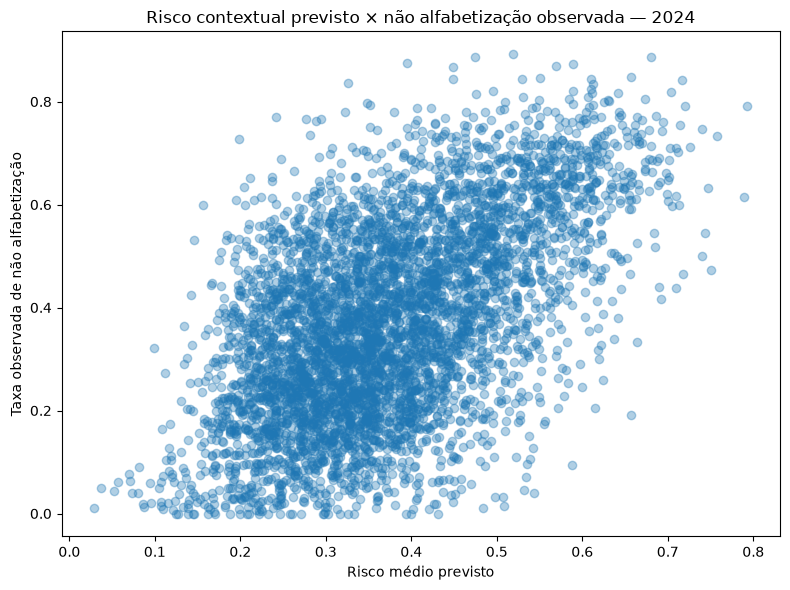

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    validacao_municipal["risco_medio"],
    validacao_municipal["taxa_nao_alfabetizado_observada"],
    alpha=0.35,
)

plt.xlabel("Risco médio previsto")
plt.ylabel("Taxa observada de não alfabetização")
plt.title(
    "Risco contextual previsto × não alfabetização observada — 2024"
)

plt.tight_layout()
plt.show()

#### Interpretação

A correlação de Spearman entre o risco contextual previsto e a taxa observada de não alfabetização em 2024 foi de **0,5312**, indicando associação positiva moderada entre os indicadores.

O resultado mostra que municípios classificados pelo modelo com maior risco tendem, em geral, a apresentar maiores taxas observadas de não alfabetização.

Entretanto, a dispersão observada evidencia que o risco previsto não reproduz exatamente a taxa municipal observada. Dessa forma, o indicador deve ser utilizado como instrumento de **priorização territorial e identificação de contextos educacionais de maior risco**, e não como estimativa direta da taxa de não alfabetização de cada município.

### 4.5.2 Persistência da validação municipal

A base utilizada para validar a associação entre o risco contextual previsto e a taxa observada de não alfabetização é persistida como artefato intermediário do projeto.

Esse artefato permite reproduzir visualizações e análises de validação municipal sem recalcular as agregações do notebook.

In [15]:
from pathlib import Path

OUTPUT_VALIDACAO_MUNICIPAL = Path(
    "../data/processed/validacao_municipal_2024.parquet"
)

colunas_validacao_municipal = [
    "posicao",
    "id_municipio",
    "id_municipio_nome",
    "alunos_avaliados",
    "escolas",
    "risco_medio",
    "taxa_nao_alfabetizado_observada",
]

validacao_municipal_persistida = (
    validacao_municipal[
        colunas_validacao_municipal
    ]
    .copy()
)

if validacao_municipal_persistida["id_municipio"].duplicated().any():
    raise RuntimeError(
        "Foram encontrados municípios duplicados na base de validação."
    )

OUTPUT_VALIDACAO_MUNICIPAL.parent.mkdir(
    parents=True,
    exist_ok=True,
)

validacao_municipal_persistida.to_parquet(
    OUTPUT_VALIDACAO_MUNICIPAL,
    index=False,
)

print(
    f"Arquivo salvo em: {OUTPUT_VALIDACAO_MUNICIPAL}"
)
print(
    f"Municípios persistidos: "
    f"{len(validacao_municipal_persistida):,}"
)

display(
    validacao_municipal_persistida.head()
)

Arquivo salvo em: ../data/processed/validacao_municipal_2024.parquet
Municípios persistidos: 4,973


,posicao,id_municipio,id_municipio_nome,alunos_avaliados,escolas,risco_medio,taxa_nao_alfabetizado_observada
0,1,2907202,Casa Nova,430,15,0.7931,0.7907
1,2,1703842,Campos Lindos,148,2,0.7895,0.6149
2,3,2805406,Poço Redondo,345,9,0.7571,0.7333
3,4,1701309,Aragominas,55,3,0.7502,0.4727
4,5,2910859,Filadélfia,136,7,0.7469,0.6324


## 5. Identificação de perfis municipais semelhantes

Considerando a granularidade disponível, a análise de similaridade é realizada entre municípios, tratados como unidades territoriais de comparação.”

Nesta etapa, são investigados grupos de municípios que apresentam características semelhantes de contexto e infraestrutura escolar.

A clusterização é realizada utilizando características contextuais do Censo Escolar. O risco previsto pelo modelo não é utilizado na formação dos grupos, sendo incorporado posteriormente apenas para caracterizar os perfis encontrados.

Essa separação permite verificar se diferentes contextos educacionais apresentam padrões distintos de risco de não alfabetização.

### 5.1 Construção da base municipal

In [16]:
BASE_MODELAGEM_PATH = (
    DATA_DIR
    / "processed"
    / "alunos_modelagem_enriquecido.parquet"
)

base_modelagem = pd.read_parquet(BASE_MODELAGEM_PATH)

base_2024 = base_modelagem.loc[
    base_modelagem["ano"] == 2024
].copy()

print(f"Linhas 2024: {len(base_2024):,}")
print(f"Municípios: {base_2024['id_municipio'].nunique():,}")
print(f"Colunas: {base_2024.shape[1]}")

Linhas 2024: 1,851,852
Municípios: 5,517
Colunas: 97


In [17]:
colunas_contexto = [
    coluna
    for coluna in base_2024.columns
    if (
        coluna.startswith("pct_")
        or coluna.startswith("media_qt_")
        or coluna.startswith("total_qt_")
        or coluna in [
            "qtd_escolas",
            "alunos_por_docente",
            "alunos_por_sala",
            "dispositivos_aluno_por_100_matriculas",
        ]
    )
]

print(f"Características contextuais encontradas: {len(colunas_contexto)}")

pd.DataFrame({
    "variavel": colunas_contexto
})

Características contextuais encontradas: 41


,variavel
0,qtd_escolas
1,pct_info_detalhada_completa
2,pct_tp_localizacao_1
3,pct_tp_localizacao_2
4,pct_localizacao_diferenciada
5,pct_in_agua_potavel
6,pct_in_agua_rede_publica
7,pct_in_energia_rede_publica
8,pct_in_esgoto_rede_publica
9,pct_in_lixo_servico_coleta


### 5.2 Seleção das características para clusterização

A clusterização utiliza características contextuais agregadas no nível municipal.

São excluídas variáveis redundantes, indicadores auxiliares de qualidade e medidas absolutas cuja magnitude é diretamente influenciada pelo porte do município. Para os recursos tecnológicos disponíveis aos alunos, são mantidas as respectivas versões normalizadas, permitindo comparar municípios de diferentes tamanhos com menor influência da escala populacional.

O risco previsto e os resultados observados de alfabetização não são utilizados na formação dos clusters, sendo empregados posteriormente apenas para caracterização e interpretação dos grupos identificados.

In [18]:
exclusoes_cluster = {
    "pct_tp_localizacao_2",
    "total_qt_salas_utilizadas",
    "total_qt_mat_bas",
    "total_qt_doc_bas",
    "total_qt_desktop_aluno",
    "total_qt_comp_portatil_aluno",
    "total_qt_tablet_aluno",
    "pct_info_detalhada_completa",
}

features_cluster = [
    coluna
    for coluna in colunas_contexto
    if coluna not in exclusoes_cluster
]

print(f"Características disponíveis: {len(colunas_contexto)}")
print(f"Excluídas: {len(exclusoes_cluster)}")
print(f"Selecionadas para clusterização: {len(features_cluster)}")

pd.DataFrame({
    "variavel": features_cluster
})

Características disponíveis: 41
Excluídas: 8
Selecionadas para clusterização: 33


,variavel
0,qtd_escolas
1,pct_tp_localizacao_1
2,pct_localizacao_diferenciada
3,pct_in_agua_potavel
4,pct_in_agua_rede_publica
5,pct_in_energia_rede_publica
6,pct_in_esgoto_rede_publica
7,pct_in_lixo_servico_coleta
8,pct_in_banheiro_pne
9,pct_in_biblioteca


### 5.3 Agregação das características por município

Para a análise de similaridade, as características contextuais são agregadas no nível municipal.

Cada município passa a ser representado por um vetor de características médias relacionadas à infraestrutura, conectividade, recursos escolares e organização da rede de ensino.

Essa transformação evita que municípios com maior número de alunos tenham maior peso na etapa de clusterização.

In [19]:
base_cluster_municipio = (
    base_2024
    .groupby(
        ["id_municipio", "id_municipio_nome"],
        as_index=False,
    )[features_cluster]
    .mean()
)

print(f"Municípios: {len(base_cluster_municipio):,}")
print(f"Características: {len(features_cluster)}")

base_cluster_municipio.head()

Municípios: 5,517
Características: 33


,id_municipio,id_municipio_nome,qtd_escolas,pct_tp_localizacao_1,pct_localizacao_diferenciada,pct_in_agua_potavel,pct_in_agua_rede_publica,pct_in_energia_rede_publica,pct_in_esgoto_rede_publica,pct_in_lixo_servico_coleta,pct_in_banheiro_pne,pct_in_biblioteca,pct_in_biblioteca_sala_leitura,pct_in_laboratorio_ciencias,pct_in_laboratorio_informatica,pct_in_patio_coberto,pct_in_patio_descoberto,pct_in_parque_infantil,pct_in_quadra_esportes,pct_in_acessibilidade_corrimao,pct_in_acessibilidade_rampas,pct_in_acessibilidade_sinal_visual,pct_in_computador,pct_in_internet,pct_in_internet_aprendizagem,pct_in_banda_larga,media_qt_salas_utilizadas,media_qt_desktop_aluno,media_qt_comp_portatil_aluno,media_qt_tablet_aluno,media_qt_mat_bas,media_qt_doc_bas,alunos_por_docente,alunos_por_sala,dispositivos_aluno_por_100_matriculas
0,1100015,Alta Floresta D'Oeste,14.0000,71.4286,0.0000,100.0000,28.5714,100.0000,0.0000,50.0000,28.5714,28.5714,42.8571,0.0000,0.0000,85.7143,14.2857,28.5714,71.4286,7.1429,35.7143,7.1429,92.8571,100.0000,50.0000,42.8571,7.9286,0.1429,0.1429,0.0000,189.1429,13.5714,13.9368,23.8559,0.1511
1,1100023,Ariquemes,27.0000,74.0741,3.7037,96.2963,81.4815,100.0000,0.0000,100.0000,74.0741,59.2593,62.9630,3.7037,85.1852,88.8889,40.7407,85.1852,55.5556,44.4444,74.0741,0.0000,100.0000,100.0000,85.1852,81.4815,10.4444,15.9630,1.7778,0.5556,377.0741,15.8519,23.7874,36.1028,4.8522
2,1100031,Cabixi,4.0000,100.0000,0.0000,100.0000,75.0000,100.0000,0.0000,100.0000,25.0000,25.0000,25.0000,0.0000,25.0000,50.0000,75.0000,25.0000,75.0000,0.0000,0.0000,0.0000,100.0000,100.0000,25.0000,50.0000,6.7500,0.2500,0.2500,0.0000,149.7500,12.3333,16.1892,22.1852,0.3339
3,1100049,Cacoal,25.5110,62.1381,5.6691,100.0000,61.4294,100.0000,51.0630,81.4538,68.5766,43.5310,43.5310,15.3269,17.0681,57.1168,65.4182,74.0435,38.8945,28.9127,67.4833,9.9817,96.0721,100.0000,92.1442,74.3066,8.8198,5.2446,0.6453,0.5139,278.7933,14.3409,19.3489,30.4924,2.1285
4,1100056,Cerejeiras,7.0000,100.0000,0.0000,100.0000,71.4286,100.0000,100.0000,100.0000,71.4286,0.0000,42.8571,0.0000,0.0000,85.7143,42.8571,42.8571,42.8571,42.8571,85.7143,0.0000,100.0000,100.0000,100.0000,0.0000,7.2857,0.1429,0.0000,0.0000,242.5714,13.2857,18.2581,33.2941,0.0589


### 5.4 Validação da base agregada

In [20]:
nulos_cluster = (
    base_cluster_municipio[features_cluster]
    .isna()
    .sum()
)

variancias_cluster = (
    base_cluster_municipio[features_cluster]
    .var()
)

print(
    "Variáveis com nulos:",
    (nulos_cluster > 0).sum(),
)

print(
    "Variáveis com variância zero:",
    (variancias_cluster == 0).sum(),
)

display(
    nulos_cluster[
        nulos_cluster > 0
    ].to_frame("nulos")
)

display(
    variancias_cluster[
        variancias_cluster == 0
    ].to_frame("variancia")
)

Variáveis com nulos: 1
Variáveis com variância zero: 0


,nulos
pct_in_banda_larga,1


,variancia


### 5.5 Tratamento de valor ausente

Foi identificado um único valor ausente na variável `pct_in_banda_larga`.

Para preservar o município na análise e manter consistência com o tratamento utilizado na etapa de modelagem, o valor ausente é substituído pela mediana da variável calculada sobre a base municipal.

In [21]:
mediana_banda_larga = (
    base_cluster_municipio["pct_in_banda_larga"]
    .median()
)

base_cluster_municipio["pct_in_banda_larga"] = (
    base_cluster_municipio["pct_in_banda_larga"]
    .fillna(mediana_banda_larga)
)

print(f"Mediana utilizada: {mediana_banda_larga:.4f}")

print(
    "Total de nulos após tratamento:",
    base_cluster_municipio[features_cluster]
    .isna()
    .sum()
    .sum()
)

Mediana utilizada: 93.9434
Total de nulos após tratamento: 0


### 5.6 Padronização das características

As características municipais apresentam diferentes escalas de medida. Para evitar que variáveis de maior magnitude tenham influência desproporcional na formação dos grupos, as características são padronizadas para média zero e desvio-padrão unitário.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()

X_cluster = scaler_cluster.fit_transform(
    base_cluster_municipio[features_cluster]
)

print(f"Dimensões da matriz: {X_cluster.shape}")
print(f"Média aproximada: {X_cluster.mean():.6f}")
print(f"Desvio-padrão aproximado: {X_cluster.std():.6f}")

Dimensões da matriz: (5517, 33)
Média aproximada: 0.000000
Desvio-padrão aproximado: 1.000000


### 5.7 Escolha do número de clusters

Para identificar grupos de municípios com características contextuais semelhantes, é utilizado o algoritmo K-Means sobre as características previamente padronizadas.

O número de clusters não é definido arbitrariamente. São avaliadas diferentes quantidades de grupos utilizando:

- **Inércia:** mede a dispersão interna dos clusters; valores menores indicam grupos mais compactos.
- **Silhouette Score:** avalia simultaneamente a coesão interna e a separação entre os clusters; valores maiores indicam melhor estrutura de agrupamento.

As métricas são analisadas conjuntamente para apoiar a escolha do número de clusters.

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados_k = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    labels = kmeans.fit_predict(X_cluster)

    resultados_k.append({
        "k": k,
        "inercia": kmeans.inertia_,
        "silhouette": silhouette_score(
            X_cluster,
            labels,
        ),
    })

avaliacao_k = pd.DataFrame(resultados_k)

avaliacao_k

,k,inercia,silhouette
0,2,150412.0625,0.1882
1,3,141022.0408,0.1059
2,4,134913.3972,0.0936
3,5,126881.5344,0.1001
4,6,122562.9522,0.0927
5,7,117212.6813,0.0893
6,8,114256.7041,0.0909
7,9,111722.4644,0.0805
8,10,106496.6116,0.0834


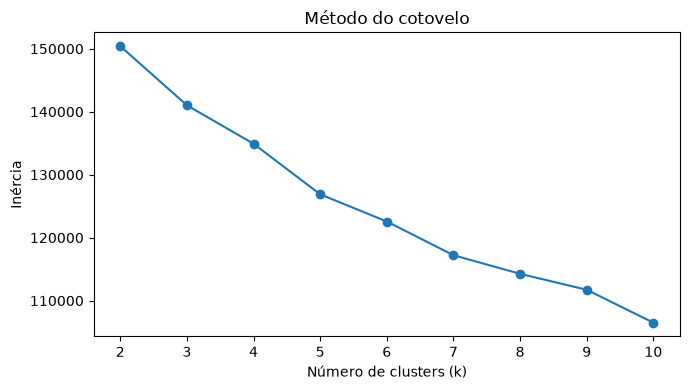

In [24]:
plt.figure(figsize=(7, 4))

plt.plot(
    avaliacao_k["k"],
    avaliacao_k["inercia"],
    marker="o",
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.title("Método do cotovelo")

plt.tight_layout()
plt.show()

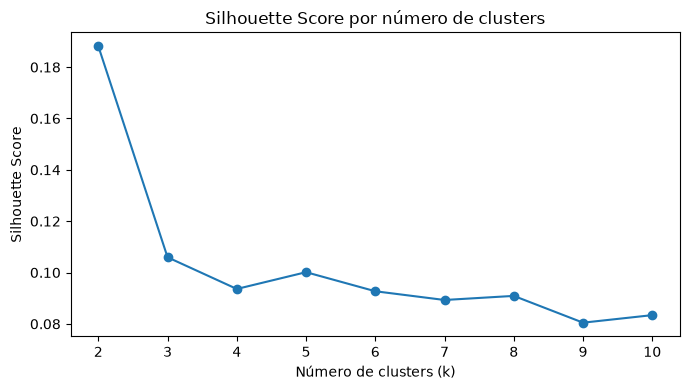

In [25]:
plt.figure(figsize=(7, 4))

plt.plot(
    avaliacao_k["k"],
    avaliacao_k["silhouette"],
    marker="o",
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por número de clusters")

plt.tight_layout()
plt.show()

### 5.8 Definição da solução de clusterização

Entre as configurações avaliadas, a solução com dois clusters apresentou o maior Silhouette Score (`0,1882`).

Embora esse valor indique separação limitada entre os grupos, a solução com dois clusters apresentou desempenho substancialmente superior às demais configurações testadas. O método do cotovelo, por sua vez, não revelou uma quebra claramente definida na redução da inércia.

Dessa forma, são adotados dois clusters como uma segmentação exploratória dos municípios. Os grupos não devem ser interpretados como categorias naturais rígidas, mas como perfis contextuais úteis para comparação e análise estratégica.

In [26]:
K_FINAL = 2

kmeans_final = KMeans(
    n_clusters=K_FINAL,
    random_state=RANDOM_STATE,
    n_init=10,
)

base_cluster_municipio["cluster"] = (
    kmeans_final.fit_predict(X_cluster)
)

base_cluster_municipio["cluster"].value_counts().sort_index()

cluster
0    3574
1    1943
Name: count, dtype: int64

In [27]:
perfil_clusters = (
    base_cluster_municipio
    .groupby("cluster")[features_cluster]
    .mean()
    .T
)

perfil_clusters["diferenca"] = (
    perfil_clusters[1] - perfil_clusters[0]
)

perfil_clusters["diferenca_abs"] = (
    perfil_clusters["diferenca"].abs()
)

perfil_clusters = (
    perfil_clusters
    .sort_values(
        "diferenca_abs",
        ascending=False,
    )
)

perfil_clusters.head(20)

cluster,0,1,diferenca,diferenca_abs
media_qt_mat_bas,230.9287,153.7542,-77.1745,77.1745
pct_tp_localizacao_1,79.9414,36.7778,-43.1635,43.1635
pct_in_parque_infantil,50.1286,9.7007,-40.4278,40.4278
pct_in_esgoto_rede_publica,56.9119,20.2394,-36.6725,36.6725
pct_in_lixo_servico_coleta,95.6867,60.3952,-35.2915,35.2915
pct_in_internet_aprendizagem,78.8599,44.0354,-34.8245,34.8245
pct_in_agua_rede_publica,88.1361,54.0594,-34.0767,34.0767
pct_in_biblioteca_sala_leitura,60.0078,26.6792,-33.3287,33.3287
pct_in_banheiro_pne,64.2246,32.3604,-31.8642,31.8642
pct_in_patio_descoberto,63.9945,34.8245,-29.1700,29.1700


### 5.9 Caracterização dos perfis municipais

Após a formação dos clusters, os grupos são relacionados aos indicadores de risco produzidos anteriormente.

O risco previsto e a taxa observada de não alfabetização não participaram da formação dos clusters. Eles são utilizados nesta etapa apenas para caracterizar os perfis encontrados e verificar se diferentes contextos municipais estão associados a diferentes níveis de risco educacional.

In [28]:
clusters_risco = (
    base_cluster_municipio[
        [
            "id_municipio",
            "id_municipio_nome",
            "cluster",
        ]
    ]
    .merge(
        validacao_municipal[
            [
                "id_municipio",
                "risco_medio",
                "taxa_nao_alfabetizado_observada",
            ]
        ],
        on="id_municipio",
        how="left",
    )
)

perfil_risco_clusters = (
    clusters_risco
    .groupby("cluster")
    .agg(
        municipios=("id_municipio", "size"),
        risco_medio=("risco_medio", "mean"),
        taxa_observada=(
            "taxa_nao_alfabetizado_observada",
            "mean",
        ),
    )
)

perfil_risco_clusters

,municipios,risco_medio,taxa_observada
cluster,,,
0,3574,0.3301,0.3327
1,1943,0.4477,0.4379


### 5.9.1 Principais diferenças contextuais

In [29]:
principais_diferencas = (
    perfil_clusters
    .head(15)
    [[0, 1, "diferenca"]]
    .copy()
)

principais_diferencas.columns = [
    "cluster_0",
    "cluster_1",
    "diferenca_1_menos_0",
]

principais_diferencas

,cluster_0,cluster_1,diferenca_1_menos_0
media_qt_mat_bas,230.9287,153.7542,-77.1745
pct_tp_localizacao_1,79.9414,36.7778,-43.1635
pct_in_parque_infantil,50.1286,9.7007,-40.4278
pct_in_esgoto_rede_publica,56.9119,20.2394,-36.6725
pct_in_lixo_servico_coleta,95.6867,60.3952,-35.2915
pct_in_internet_aprendizagem,78.8599,44.0354,-34.8245
pct_in_agua_rede_publica,88.1361,54.0594,-34.0767
pct_in_biblioteca_sala_leitura,60.0078,26.6792,-33.3287
pct_in_banheiro_pne,64.2246,32.3604,-31.8642
pct_in_patio_descoberto,63.9945,34.8245,-29.1700


### 5.9.2 Interpretação dos perfis

A análise identificou dois perfis contextuais de municípios.

O **Cluster 0**, composto por 3.574 municípios, apresenta valores médios superiores em diversas características relacionadas à infraestrutura e aos recursos escolares, incluindo materiais escolares, saneamento, conectividade, biblioteca ou sala de leitura, equipamentos e outros recursos do ambiente escolar. Nesse grupo, o risco médio previsto de não alfabetização foi de **33,01%**, enquanto a taxa observada foi de **33,27%**.

O **Cluster 1**, composto por 1.943 municípios, apresenta valores médios inferiores em várias das características que mais diferenciam os grupos. Esse perfil apresentou risco médio previsto de **44,77%** e taxa observada de não alfabetização de **43,79%**.

A formação dos grupos utiliza características contextuais comparáveis entre municípios, excluindo medidas absolutas de equipamentos diretamente influenciadas pela escala municipal. Mesmo após essa adequação, a segmentação manteve a associação entre diferentes contextos educacionais e diferentes níveis de risco.

Portanto, o grupo caracterizado por menor disponibilidade média de diferentes recursos escolares apresenta também maior risco previsto e maior taxa observada de não alfabetização.

Esses resultados são associativos e não permitem concluir que as diferenças de infraestrutura sejam causas diretas das diferenças de alfabetização.

## 5.10 Conclusão — padrões de similaridade entre municípios

A análise de cluster identificou dois grandes perfis de municípios a partir das características de infraestrutura, conectividade, recursos escolares e organização da rede de ensino.

Para reduzir a influência direta da escala municipal na formação dos grupos, medidas absolutas de equipamentos foram excluídas quando estavam disponíveis medidas normalizadas correspondentes. Após essa adequação, a solução com dois clusters permaneceu como a configuração de melhor desempenho entre as avaliadas.

O **Cluster 0**, composto por 3.574 municípios, apresenta de forma geral maiores indicadores de disponibilidade de recursos escolares. O **Cluster 1**, com 1.943 municípios, apresenta valores inferiores em diversas características contextuais, incluindo disponibilidade de equipamentos, conectividade e infraestrutura escolar.

A relação desses agrupamentos com os resultados de alfabetização reforça a relevância da segmentação. O risco médio previsto de não alfabetização foi de **33,01% no cluster 0 e 44,77% no cluster 1**. A mesma ordenação aparece no resultado observado de 2024, com taxas médias de não alfabetização de **33,27% e 43,79%**, respectivamente.

Assim, a clusterização permite identificar municípios que compartilham contextos educacionais semelhantes e mostra que o grupo caracterizado por menor disponibilidade média de diferentes recursos escolares também apresenta, em média, maior vulnerabilidade educacional.

Do ponto de vista estratégico, os clusters podem apoiar políticas diferenciadas: em vez de tratar todos os municípios de forma homogênea, municípios pertencentes a contextos semelhantes podem ser analisados conjuntamente para orientar diagnósticos e estratégias de intervenção compatíveis com suas características.

A clusterização representa uma análise de similaridade e não estabelece relações causais entre infraestrutura escolar e alfabetização.

> **Sustenta parcialmente H5**: os clusters construídos exclusivamente a partir das características contextuais apresentam diferenças coerentes de risco previsto e de não alfabetização observada. Entretanto, o baixo silhouette (0,1882) indica separação limitada entre os perfis, de modo que os resultados oferecem suporte parcial à hipótese, sem caracterizar grupos municipais rigidamente distintos.

## 6. Priorização municipal frente às metas futuras
Esta seção responde à questão estratégica sobre quais municípios apresentam maior risco de não atingir as metas futuras de alfabetização.

As metas municipais não foram utilizadas como variáveis explicativas no modelo final, evitando que informações diretamente relacionadas ao resultado esperado dominassem a predição.

Nesta etapa, elas são reincorporadas exclusivamente como referência externa para avaliar os municípios a partir do risco contextual estimado pelo modelo.

O objetivo não é produzir uma previsão pontual da futura taxa municipal de alfabetização, mas identificar municípios cujo contexto atual indica maior vulnerabilidade em relação às metas estabelecidas.

### 6.1 Verificação das metas disponíveis

In [30]:
colunas_meta = [
    coluna
    for coluna in base_2024.columns
    if coluna.startswith("meta_alfabetizacao_")
]

print(f"Metas encontradas: {len(colunas_meta)}")

for coluna in colunas_meta:
    print(coluna)

Metas encontradas: 7
meta_alfabetizacao_2024
meta_alfabetizacao_2025
meta_alfabetizacao_2026
meta_alfabetizacao_2027
meta_alfabetizacao_2028
meta_alfabetizacao_2029
meta_alfabetizacao_2030


In [31]:
resumo_metas = []

for coluna in colunas_meta:
    resumo_metas.append({
        "variavel": coluna,
        "nao_nulos": base_2024[coluna].notna().sum(),
        "municipios_com_meta": (
            base_2024
            .loc[base_2024[coluna].notna(), "id_municipio"]
            .nunique()
        ),
        "minimo": base_2024[coluna].min(),
        "mediana": base_2024[coluna].median(),
        "maximo": base_2024[coluna].max(),
    })

resumo_metas = pd.DataFrame(resumo_metas)

resumo_metas

,variavel,nao_nulos,municipios_com_meta,minimo,mediana,maximo
0,meta_alfabetizacao_2024,1568597,5232,7.9400,60.1400,80.0000
1,meta_alfabetizacao_2025,1588619,5352,14.0500,63.8800,80.0000
2,meta_alfabetizacao_2026,1588619,5352,23.6500,67.5500,80.0000
3,meta_alfabetizacao_2027,1588619,5352,37.0000,71.0200,80.0000
4,meta_alfabetizacao_2028,1588619,5352,52.6800,74.2700,80.0000
5,meta_alfabetizacao_2029,1588619,5352,67.8500,77.2600,80.0000
6,meta_alfabetizacao_2030,1588619,5352,80.0000,80.0000,80.0000


### 6.2 Construção do indicador de risco frente às metas

> **Nota metodológica:** as subseções 6.2 a 6.5 registram uma abordagem exploratória inicialmente avaliada para relacionar o risco previsto às metas futuras. A validação apresentada posteriormente mostrou limitações nessa formulação, que não foi adotada como metodologia final. A abordagem definitiva é apresentada a partir da seção 6.7.

Para relacionar o risco produzido pelo modelo às metas futuras, é construído um indicador municipal de alfabetização contextual estimada, definido como o complemento do risco médio previsto de não alfabetização.

Esse indicador não representa uma previsão pontual da futura taxa de alfabetização do município. Ele funciona como uma medida de referência derivada do modelo para avaliar a distância entre o contexto de risco atual e as metas estabelecidas.

A comparação é utilizada para identificar municípios que apresentam maior vulnerabilidade em relação ao cumprimento das metas futuras.

In [32]:
metas_municipio = (
    base_2024[
        ["id_municipio", "id_municipio_nome"] + colunas_meta
    ]
    .groupby(
        ["id_municipio", "id_municipio_nome"],
        as_index=False,
    )
    .first()
)

risco_metas = (
    validacao_municipal[
        [
            "id_municipio",
            "id_municipio_nome",
            "risco_medio",
            "taxa_nao_alfabetizado_observada",
        ]
    ]
    .merge(
        metas_municipio,
        on=["id_municipio", "id_municipio_nome"],
        how="left",
    )
)

risco_metas["alfabetizacao_contextual_estimada"] = (
    1 - risco_metas["risco_medio"]
) * 100

print(f"Municípios: {len(risco_metas):,}")

risco_metas[
    [
        "risco_medio",
        "alfabetizacao_contextual_estimada",
    ] + colunas_meta
].describe().T

Municípios: 4,973


,count,mean,std,min,25%,50%,75%,max
risco_medio,4973.0000,0.3727,0.1202,0.0292,0.2842,0.3585,0.4518,0.7931
alfabetizacao_contextual_estimada,4973.0000,62.7297,12.0181,20.6946,54.8242,64.1504,71.5777,97.0849
meta_alfabetizacao_2024,4764.0000,61.7757,14.9571,8.2500,51.9350,63.4550,74.9800,80.0000
meta_alfabetizacao_2025,4859.0000,64.9485,12.4873,14.4800,56.8400,66.4700,75.7850,80.0000
meta_alfabetizacao_2026,4859.0000,68.3317,9.7323,24.1600,62.1900,69.5300,76.6750,80.0000
meta_alfabetizacao_2027,4859.0000,71.6110,6.9656,37.4900,67.2500,72.4200,77.5400,80.0000
meta_alfabetizacao_2028,4859.0000,74.6929,4.3393,53.0300,71.9500,75.1300,78.3850,80.0000
meta_alfabetizacao_2029,4859.0000,77.5037,1.9902,68.0000,76.2100,77.6600,79.2000,80.0000
meta_alfabetizacao_2030,4859.0000,80.0000,0.0000,80.0000,80.0000,80.0000,80.0000,80.0000


### 6.3 Distância contextual em relação às metas futuras

A vulnerabilidade em relação às metas é avaliada pela diferença entre o indicador de alfabetização contextual estimada e a meta estabelecida para cada município.

Valores negativos indicam que o nível de alfabetização associado ao contexto de risco atual encontra-se abaixo da meta de referência. Quanto maior a distância negativa, maior a vulnerabilidade do município em relação à meta.

Essa medida deve ser interpretada como um indicador de risco estratégico, e não como uma previsão pontual da taxa futura de alfabetização.

In [33]:
anos_futuros = range(2025, 2031)

for ano in anos_futuros:
    coluna_meta = f"meta_alfabetizacao_{ano}"
    coluna_gap = f"gap_meta_{ano}"

    risco_metas[coluna_gap] = (
        risco_metas["alfabetizacao_contextual_estimada"]
        - risco_metas[coluna_meta]
    )

In [34]:
resumo_risco_metas = []

for ano in anos_futuros:
    coluna_meta = f"meta_alfabetizacao_{ano}"
    coluna_gap = f"gap_meta_{ano}"

    base_ano = risco_metas.dropna(
        subset=[coluna_meta, coluna_gap]
    )

    abaixo_meta = base_ano[coluna_gap] < 0

    resumo_risco_metas.append({
        "ano": ano,
        "municipios_avaliados": len(base_ano),
        "municipios_abaixo_referencia": abaixo_meta.sum(),
        "pct_abaixo_referencia": abaixo_meta.mean() * 100,
        "gap_mediano_pp": base_ano[coluna_gap].median(),
    })

resumo_risco_metas = pd.DataFrame(resumo_risco_metas)

resumo_risco_metas

,ano,municipios_avaliados,municipios_abaixo_referencia,pct_abaixo_referencia,gap_mediano_pp
0,2025,4859,3043,62.6261,-2.7366
1,2026,4859,3694,76.0239,-5.6803
2,2027,4859,4133,85.0587,-8.6412
3,2028,4859,4404,90.6359,-11.3737
4,2029,4859,4537,93.3731,-13.7080
5,2030,4859,4594,94.5462,-15.8378


### 6.4 Ranking de vulnerabilidade à meta de 2025

A meta de 2025 é utilizada para a priorização por representar o horizonte futuro mais próximo do período utilizado para validação do modelo.

Os municípios são ordenados pela distância entre o indicador de alfabetização contextual estimada e a meta de 2025. Valores mais negativos representam maior distância em relação à referência estabelecida e, portanto, maior vulnerabilidade contextual.

O ranking deve ser utilizado como instrumento de priorização e não como previsão determinística de descumprimento da meta.

In [35]:
ranking_meta_2025 = (
    risco_metas
    .dropna(
        subset=[
            "meta_alfabetizacao_2025",
            "gap_meta_2025",
        ]
    )
    .sort_values(
        "gap_meta_2025",
        ascending=True,
    )
    .reset_index(drop=True)
)

ranking_meta_2025["posicao"] = (
    ranking_meta_2025.index + 1
)

ranking_meta_2025[
    [
        "posicao",
        "id_municipio",
        "id_municipio_nome",
        "risco_medio",
        "alfabetizacao_contextual_estimada",
        "meta_alfabetizacao_2025",
        "gap_meta_2025",
        "taxa_nao_alfabetizado_observada",
    ]
].head(20)

,posicao,id_municipio,id_municipio_nome,risco_medio,alfabetizacao_contextual_estimada,meta_alfabetizacao_2025,gap_meta_2025,taxa_nao_alfabetizado_observada
0,1,2110609,São Bernardo,0.6181,38.1902,76.1200,-37.9298,0.3178
1,2,2204600,Hugo Napoleão,0.5562,44.3753,80.0000,-35.6247,0.1800
2,3,2207777,Patos do Piauí,0.5342,46.5814,80.0000,-33.4186,0.3696
3,4,3532058,Motuca,0.5290,47.1020,79.9500,-32.8480,0.2195
4,5,2207751,Passagem Franca do Piauí,0.5220,47.8018,80.0000,-32.1982,0.3571
5,6,2202604,Castelo do Piauí,0.5557,44.4336,76.5700,-32.1364,0.1737
6,7,4203154,Calmon,0.6349,36.5076,68.4600,-31.9524,0.4133
7,8,2111409,São Luís Gonzaga do Maranhão,0.5525,44.7542,76.3800,-31.6258,0.3030
8,9,2305605,Independência,0.5085,49.1535,80.0000,-30.8465,0.0140
9,10,2205516,Juazeiro do Piauí,0.5814,41.8610,72.2600,-30.3990,0.2791


### 6.5 Validação do indicador de vulnerabilidade

Como o indicador contextual não representa uma previsão direta da taxa futura de alfabetização, sua utilidade para priorização é avaliada em relação ao resultado efetivamente observado em 2024.

Espera-se que municípios classificados com maior vulnerabilidade à meta de 2025 apresentem, em média, maiores taxas observadas de não alfabetização.

Essa análise funciona como uma validação adicional da coerência do indicador para fins de priorização estratégica.

In [36]:
correlacao_gap_observado = (
    ranking_meta_2025[
        [
            "gap_meta_2025",
            "taxa_nao_alfabetizado_observada",
        ]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print(
    "Correlação de Spearman entre gap da meta e "
    f"não alfabetização observada: {correlacao_gap_observado:.4f}"
)

Correlação de Spearman entre gap da meta e não alfabetização observada: 0.1587


In [37]:
ranking_meta_2025["quintil_vulnerabilidade"] = pd.qcut(
    ranking_meta_2025["gap_meta_2025"],
    q=5,
    labels=[
        "Q1 - maior vulnerabilidade",
        "Q2",
        "Q3",
        "Q4",
        "Q5 - menor vulnerabilidade",
    ],
)

validacao_quintis = (
    ranking_meta_2025
    .groupby(
        "quintil_vulnerabilidade",
        observed=True,
    )
    .agg(
        municipios=("id_municipio", "size"),
        gap_medio_pp=("gap_meta_2025", "mean"),
        risco_medio=("risco_medio", "mean"),
        taxa_nao_alfabetizado_observada=(
            "taxa_nao_alfabetizado_observada",
            "mean",
        ),
    )
)

validacao_quintis

,municipios,gap_medio_pp,risco_medio,taxa_nao_alfabetizado_observada
quintil_vulnerabilidade,,,,
Q1 - maior vulnerabilidade,972,-14.1494,0.4431,0.3348
Q2,972,-6.9191,0.3941,0.3564
Q3,971,-2.6673,0.3584,0.3595
Q4,972,1.8352,0.3381,0.3691
Q5 - menor vulnerabilidade,972,10.9705,0.3281,0.4263


#### Resultado da validação exploratória

A validação não confirmou o comportamento esperado para o indicador inicialmente proposto.

A correlação entre o gap da meta e a taxa observada de não alfabetização foi positiva (Spearman = 0,1587), quando seria esperada uma associação negativa caso o indicador estivesse ordenando adequadamente os municípios segundo sua vulnerabilidade.

A análise por quintis reforça esse resultado, pois os grupos classificados como de menor vulnerabilidade pelo gap inicial apresentaram, em média, maiores taxas observadas de não alfabetização.

Por esse motivo, essa formulação não é adotada como indicador final de priorização. As etapas seguintes investigam a origem desse comportamento e constroem uma abordagem alternativa.

### 6.6 Diagnóstico das metas

In [38]:
risco_metas["taxa_alfabetizacao_observada"] = (
    1 - risco_metas["taxa_nao_alfabetizado_observada"]
) * 100

diagnostico_metas = risco_metas[
    [
        "taxa_alfabetizacao_observada",
        "meta_alfabetizacao_2024",
        "meta_alfabetizacao_2025",
        "risco_medio",
    ]
].corr(method="spearman")

diagnostico_metas

,taxa_alfabetizacao_observada,meta_alfabetizacao_2024,meta_alfabetizacao_2025,risco_medio
taxa_alfabetizacao_observada,1.0000,0.6631,0.6713,-0.5312
meta_alfabetizacao_2024,0.6631,1.0000,1.0000,-0.7133
meta_alfabetizacao_2025,0.6713,1.0000,1.0000,-0.7114
risco_medio,-0.5312,-0.7133,-0.7114,1.0000


In [39]:
risco_metas["gap_observado_meta_2024"] = (
    risco_metas["taxa_alfabetizacao_observada"]
    - risco_metas["meta_alfabetizacao_2024"]
)

risco_metas[
    [
        "taxa_alfabetizacao_observada",
        "meta_alfabetizacao_2024",
        "meta_alfabetizacao_2025",
        "gap_observado_meta_2024",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
taxa_alfabetizacao_observada,4973.0000,62.9198,18.6850,10.8108,48.9583,64.1350,77.4194,100.0000
meta_alfabetizacao_2024,4764.0000,61.7757,14.9571,8.2500,51.9350,63.4550,74.9800,80.0000
meta_alfabetizacao_2025,4859.0000,64.9485,12.4873,14.4800,56.8400,66.4700,75.7850,80.0000
gap_observado_meta_2024,4764.0000,1.4990,13.9444,-51.4367,-6.8766,1.4156,10.6150,68.7788


### 6.7 Abordagem final: risco contextual e desafio da meta

A análise anterior mostrou que a diferença direta entre o complemento do risco previsto e a meta municipal não produz um indicador adequado de priorização.

As metas apresentam associação com o próprio contexto educacional dos municípios, fazendo com que a construção de um único gap misture duas dimensões distintas.

Por esse motivo, a abordagem final mantém separadamente:

- **risco contextual**, representado pelo risco médio previsto pelo modelo;
- **desafio da meta**, representado pela distância entre a taxa de alfabetização observada em 2024 e a meta de 2025.

Essa abordagem evita interpretar a probabilidade produzida pelo modelo como uma previsão direta da taxa futura de alfabetização.

In [40]:
risco_metas["desafio_meta_2025_pp"] = (
    risco_metas["meta_alfabetizacao_2025"]
    - risco_metas["taxa_alfabetizacao_observada"]
)

risco_metas[
    [
        "risco_medio",
        "taxa_alfabetizacao_observada",
        "meta_alfabetizacao_2025",
        "desafio_meta_2025_pp",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
risco_medio,4973.0000,0.3727,0.1202,0.0292,0.2842,0.3585,0.4518,0.7931
taxa_alfabetizacao_observada,4973.0000,62.9198,18.6850,10.8108,48.9583,64.1350,77.4194,100.0000
meta_alfabetizacao_2025,4859.0000,64.9485,12.4873,14.4800,56.8400,66.4700,75.7850,80.0000
desafio_meta_2025_pp,4859.0000,1.8719,13.6550,-60.4288,-7.5714,1.9074,10.7876,52.7875


### 6.8 Relação entre risco e desafio

In [41]:
base_risco_meta_2025 = (
    risco_metas
    .dropna(
        subset=[
            "risco_medio",
            "meta_alfabetizacao_2025",
            "taxa_alfabetizacao_observada",
            "desafio_meta_2025_pp",
        ]
    )
    .copy()
)

print(f"Municípios analisados: {len(base_risco_meta_2025):,}")

correlacao_risco_desafio = (
    base_risco_meta_2025[
        [
            "risco_medio",
            "desafio_meta_2025_pp",
        ]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print(
    "Correlação de Spearman entre risco contextual "
    f"e desafio da meta: {correlacao_risco_desafio:.4f}"
)

base_risco_meta_2025[
    [
        "risco_medio",
        "desafio_meta_2025_pp",
    ]
].describe().T

Municípios analisados: 4,859
Correlação de Spearman entre risco contextual e desafio da meta: 0.1377


,count,mean,std,min,25%,50%,75%,max
risco_medio,4859.0000,0.3724,0.1204,0.0292,0.2836,0.3584,0.4518,0.7931
desafio_meta_2025_pp,4859.0000,1.8719,13.6550,-60.4288,-7.5714,1.9074,10.7876,52.7875


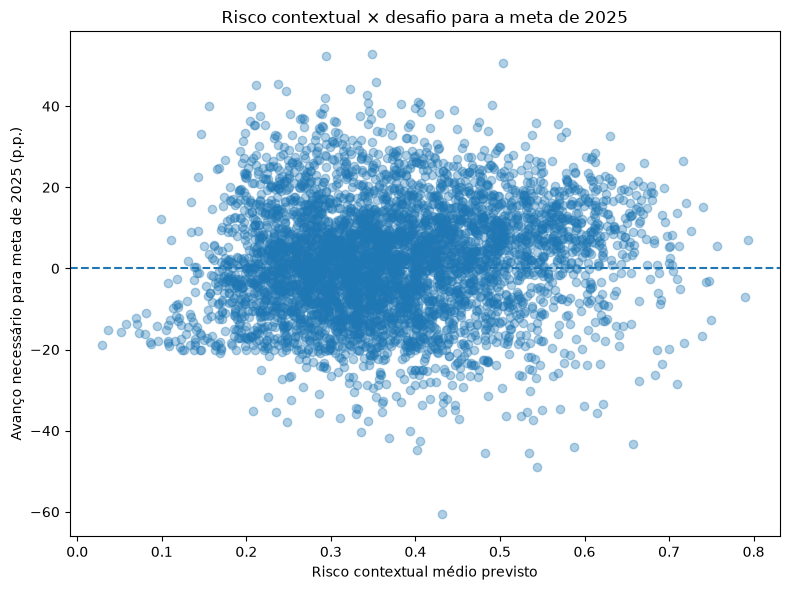

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(
    base_risco_meta_2025["risco_medio"],
    base_risco_meta_2025["desafio_meta_2025_pp"],
    alpha=0.35,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Risco contextual médio previsto")
plt.ylabel("Avanço necessário para meta de 2025 (p.p.)")
plt.title(
    "Risco contextual × desafio para a meta de 2025"
)

plt.tight_layout()
plt.show()

### 6.9 Matriz de priorização dos municípios

Para combinar as duas dimensões sem criar um índice artificial, os municípios são classificados a partir das medianas da distribuição do risco contextual e do desafio necessário para atingir a meta de 2025.

A abordagem produz quatro grupos:

- **Alto risco + alto desafio:** prioridade estratégica, pois combina contexto desfavorável segundo o modelo e maior avanço necessário para atingir a meta;
- **Alto risco + baixo desafio:** apresenta contexto de risco elevado, embora esteja relativamente próximo da meta;
- **Baixo risco + alto desafio:** apresenta contexto comparativamente mais favorável, mas necessita maior avanço para atingir a meta;
- **Baixo risco + baixo desafio:** situação comparativamente mais favorável nas duas dimensões.

Os grupos representam uma priorização relativa entre os municípios analisados e não uma previsão determinística de cumprimento ou descumprimento da meta.

In [43]:
mediana_risco = (
    base_risco_meta_2025["risco_medio"].median()
)

mediana_desafio = (
    base_risco_meta_2025["desafio_meta_2025_pp"].median()
)

print(f"Mediana do risco: {mediana_risco:.4f}")
print(
    "Mediana do desafio: "
    f"{mediana_desafio:.4f} p.p."
)

base_risco_meta_2025["priorizacao"] = np.select(
    [
        (
            (base_risco_meta_2025["risco_medio"] >= mediana_risco)
            & (base_risco_meta_2025["desafio_meta_2025_pp"] >= mediana_desafio)
        ),
        (
            (base_risco_meta_2025["risco_medio"] >= mediana_risco)
            & (base_risco_meta_2025["desafio_meta_2025_pp"] < mediana_desafio)
        ),
        (
            (base_risco_meta_2025["risco_medio"] < mediana_risco)
            & (base_risco_meta_2025["desafio_meta_2025_pp"] >= mediana_desafio)
        ),
    ],
    [
        "Alto risco + alto desafio",
        "Alto risco + baixo desafio",
        "Baixo risco + alto desafio",
    ],
    default="Baixo risco + baixo desafio",
)

resumo_priorizacao = (
    base_risco_meta_2025["priorizacao"]
    .value_counts()
    .rename_axis("grupo")
    .reset_index(name="municipios")
)

resumo_priorizacao["pct_municipios"] = (
    resumo_priorizacao["municipios"]
    / len(base_risco_meta_2025)
    * 100
)

resumo_priorizacao

Mediana do risco: 0.3584
Mediana do desafio: 1.9074 p.p.


,grupo,municipios,pct_municipios
0,Alto risco + alto desafio,1377,28.3392
1,Baixo risco + baixo desafio,1376,28.3186
2,Alto risco + baixo desafio,1053,21.6711
3,Baixo risco + alto desafio,1053,21.6711


### 6.9.1 Visualização dos quadrantes

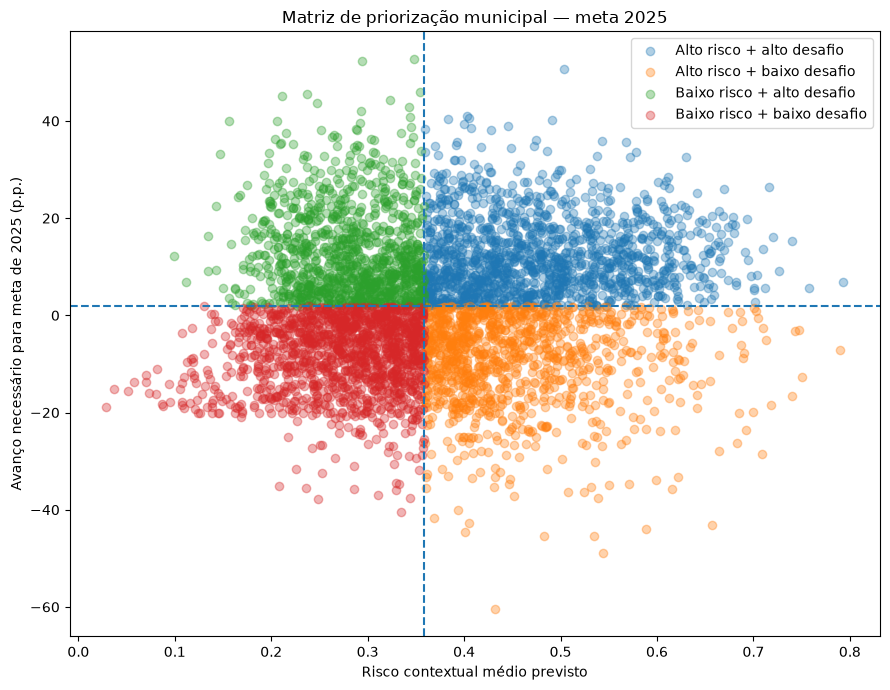

In [44]:
plt.figure(figsize=(9, 7))

for grupo, dados in base_risco_meta_2025.groupby("priorizacao"):
    plt.scatter(
        dados["risco_medio"],
        dados["desafio_meta_2025_pp"],
        alpha=0.35,
        label=grupo,
    )

plt.axvline(
    mediana_risco,
    linestyle="--",
)

plt.axhline(
    mediana_desafio,
    linestyle="--",
)

plt.xlabel("Risco contextual médio previsto")
plt.ylabel("Avanço necessário para meta de 2025 (p.p.)")
plt.title("Matriz de priorização municipal — meta 2025")
plt.legend()

plt.tight_layout()
plt.show()

### 6.9.2 Persistência da priorização municipal

A base final utilizada na matriz de priorização é persistida como artefato estratégico do projeto.

O arquivo preserva, para cada município, o risco contextual estimado, o resultado observado, a meta de 2025, o desafio necessário para cumprimento da meta e o grupo de priorização atribuído.

In [45]:
OUTPUT_PRIORIZACAO_META = Path(
    "../data/processed/priorizacao_municipal_meta_2025.parquet"
)

colunas_priorizacao = [
    "id_municipio",
    "id_municipio_nome",
    "risco_medio",
    "taxa_nao_alfabetizado_observada",
    "taxa_alfabetizacao_observada",
    "meta_alfabetizacao_2025",
    "desafio_meta_2025_pp",
    "priorizacao",
]

priorizacao_municipal_persistida = (
    base_risco_meta_2025[
        colunas_priorizacao
    ]
    .copy()
)

if priorizacao_municipal_persistida["id_municipio"].duplicated().any():
    raise RuntimeError(
        "Foram encontrados municípios duplicados na base de priorização."
    )

if priorizacao_municipal_persistida["priorizacao"].isna().any():
    raise RuntimeError(
        "Existem municípios sem classificação de priorização."
    )

OUTPUT_PRIORIZACAO_META.parent.mkdir(
    parents=True,
    exist_ok=True,
)

priorizacao_municipal_persistida.to_parquet(
    OUTPUT_PRIORIZACAO_META,
    index=False,
)

print(
    f"Arquivo salvo em: {OUTPUT_PRIORIZACAO_META}"
)
print(
    f"Municípios persistidos: "
    f"{len(priorizacao_municipal_persistida):,}"
)

display(
    priorizacao_municipal_persistida[
        [
            "id_municipio_nome",
            "risco_medio",
            "desafio_meta_2025_pp",
            "priorizacao",
        ]
    ].head()
)

Arquivo salvo em: ../data/processed/priorizacao_municipal_meta_2025.parquet
Municípios persistidos: 4,859


,id_municipio_nome,risco_medio,desafio_meta_2025_pp,priorizacao
0,Casa Nova,0.7931,6.8898,Alto risco + alto desafio
1,Campos Lindos,0.7895,-7.0835,Alto risco + baixo desafio
2,Poço Redondo,0.7571,5.6133,Alto risco + alto desafio
3,Aragominas,0.7502,-12.6773,Alto risco + baixo desafio
4,Filadélfia,0.7469,-2.9947,Alto risco + baixo desafio


### 6.10 Municípios prioritários

A priorização final considera os municípios classificados simultaneamente com alto risco contextual e alto desafio para atingir a meta de 2025.

A seleção em duas dimensões evita a criação de um índice composto arbitrário. Dentro do grupo prioritário, os municípios são ordenados pelo risco contextual previsto pelo modelo, enquanto a distância para a meta é mantida como informação complementar para apoio à decisão.

Assim, o resultado identifica territórios que combinam contexto educacional desfavorável segundo o modelo com necessidade de avanço acima da mediana para atingir a meta de 2025.

In [46]:
municipios_prioritarios = (
    base_risco_meta_2025[
        base_risco_meta_2025["priorizacao"]
        == "Alto risco + alto desafio"
    ]
    .sort_values(
        "risco_medio",
        ascending=False,
    )
    .reset_index(drop=True)
)

municipios_prioritarios["posicao"] = (
    municipios_prioritarios.index + 1
)

print(
    f"Municípios prioritários: "
    f"{len(municipios_prioritarios):,}"
)

municipios_prioritarios[
    [
        "posicao",
        "id_municipio",
        "id_municipio_nome",
        "risco_medio",
        "taxa_alfabetizacao_observada",
        "meta_alfabetizacao_2025",
        "desafio_meta_2025_pp",
    ]
].head(20)

Municípios prioritários: 1,377


,posicao,id_municipio,id_municipio_nome,risco_medio,taxa_alfabetizacao_observada,meta_alfabetizacao_2025,desafio_meta_2025_pp
0,1,2907202,Casa Nova,0.7931,20.9302,27.8200,6.8898
1,2,2805406,Poço Redondo,0.7571,26.6667,32.2800,5.6133
2,3,2919157,Lapão,0.7403,25.2492,40.4800,15.2308
3,4,2922052,Mulungu do Morro,0.7264,28.8288,38.0200,9.1912
4,5,2800209,Aquidabã,0.7202,20.9302,37.0100,16.0798
5,6,2802700,Ilha das Flores,0.7161,15.7895,42.1800,26.3905
6,7,2804805,Nossa Senhora do Socorro,0.7122,29.8039,35.4200,5.6161
7,8,2933208,Vera Cruz,0.7099,38.2716,52.0200,13.7484
8,9,1703073,Barra do Ouro,0.7039,18.0556,26.2600,8.2044
9,10,1505205,Oeiras do Pará,0.7016,31.3673,34.0500,2.6827


### 6.11 Conclusão — priorização frente às metas

A análise das metas foi realizada em duas etapas metodológicas.

Inicialmente, foi avaliada a possibilidade de comparar diretamente a taxa de alfabetização contextual estimada a partir do complemento do risco previsto pelo modelo com as metas municipais de alfabetização. Essa abordagem permitiu explorar a relação entre risco e metas, mas não foi adotada como metodologia final de priorização.

A validação mostrou que as próprias metas apresentam forte associação com o contexto educacional dos municípios. Além disso, a probabilidade produzida pelo modelo representa risco contextual de não alfabetização e não deve ser interpretada diretamente como uma estimativa da taxa futura de alfabetização. Dessa forma, a construção de um único gap entre essas grandezas poderia produzir uma interpretação inadequada.

Como abordagem final, foram mantidas duas dimensões independentes:

1. **Risco contextual:** probabilidade média de não alfabetização produzida pelo modelo;
2. **Desafio para a meta:** diferença, em pontos percentuais, entre a meta de alfabetização de 2025 e a taxa efetivamente observada em 2024.

A associação entre essas dimensões mostrou-se baixa (Spearman = 0,1377), indicando que elas fornecem informações complementares.

Para fins de priorização, foram utilizadas as medianas das duas distribuições como critérios relativos de corte. Os 4.859 municípios com informações suficientes foram classificados em quatro grupos:

- **Alto risco + alto desafio:** 1.377 municípios (28,34%);
- **Alto risco + baixo desafio:** 1.053 municípios (21,67%);
- **Baixo risco + alto desafio:** 1.053 municípios (21,67%);
- **Baixo risco + baixo desafio:** 1.376 municípios (28,32%).

Os 1.377 municípios classificados simultaneamente com alto risco contextual e alto desafio constituem o grupo prioritário para análise e eventual direcionamento de ações.

Dentro desse grupo, a ordenação pelo risco contextual permite identificar os municípios que apresentam maior vulnerabilidade segundo o modelo, mantendo a distância para a meta como informação complementar.

Essa classificação deve ser interpretada como instrumento de **priorização relativa e apoio à decisão**, e não como previsão determinística de que determinado município atingirá ou deixará de atingir sua meta.

## 7. Fatores associados aos resultados de alfabetização

Esta seção atende a duas questões complementares do Tech Challenge.

As seções **7.2 e 7.3** respondem principalmente à questão **“Quais variáveis possuem maior influência nos modelos?”**, utilizando técnicas de interpretabilidade para identificar a relevância, direção e comportamento das características nas previsões.

A seção **7.4** responde à questão **“Quais fatores mais impactam a alfabetização?”** sob uma perspectiva associativa. Os resultados de interpretabilidade são traduzidos para o contexto educacional, identificando fatores associados a maior ou menor risco previsto, sem atribuir causalidade às relações encontradas.

A análise utiliza os resultados de interpretabilidade obtidos durante a etapa de modelagem, combinando diferentes perspectivas para compreender tanto a importância global das características quanto a direção de suas associações com as previsões.

O objetivo não é estabelecer relações causais, mas transformar os resultados do modelo em evidências interpretáveis que possam apoiar a compreensão dos diferentes contextos educacionais e a definição de prioridades de análise.

Os resultados desta seção devem ser interpretados como associações preditivas: uma característica relevante para o modelo não necessariamente representa uma causa direta do resultado de alfabetização.

### 7.1 Evidências de interpretabilidade disponíveis

A etapa de modelagem avaliou a contribuição das características do contexto escolar para as previsões do modelo final por meio de técnicas complementares de interpretabilidade.

Foram utilizadas três abordagens principais:

- **Permutation Importance:** avalia quanto o desempenho preditivo do modelo se reduz quando os valores de uma característica são permutados, permitindo identificar as variáveis mais relevantes para a capacidade preditiva do modelo.
- **Partial Dependence (PDP):** permite observar como a previsão média do modelo varia ao longo dos valores de uma característica, mantendo as demais características consideradas pelo modelo.
- **SHAP:** decompõe as previsões do modelo em contribuições atribuídas às diferentes características, permitindo avaliar tanto a importância global quanto a direção das contribuições observadas.

As análises foram realizadas sobre o modelo final sem a meta municipal, definido após o teste de ablação. Essa configuração reduz o risco de utilizar a própria referência territorial de alfabetização como principal explicação das previsões e permite concentrar a interpretação nas características do contexto escolar.

Nesta seção, essas evidências são utilizadas de forma complementar para identificar os fatores com maior associação preditiva aos resultados de alfabetização. Os resultados não devem ser interpretados como estimativas de efeito causal.

### 7.2 Principais características associadas às previsões

A importância das características é analisada a partir dos resultados produzidos pelo modelo final na etapa de modelagem.

Como técnica principal de síntese global, utiliza-se a importância calculada pelos valores absolutos médios de SHAP. Essa medida representa a magnitude média da contribuição de cada característica para as previsões realizadas na amostra analisada.

A análise é complementada pelos resultados de Permutation Importance e Partial Dependence, que fornecem perspectivas distintas sobre a relevância e o comportamento das características.

A comparação entre essas técnicas não pressupõe rankings idênticos, pois cada método mede um aspecto diferente do comportamento do modelo.

In [47]:
from pathlib import Path

ARQUIVO_SHAP = Path(
    "../data/processed/importancia_shap_modelo_final.parquet"
)

importancia_shap_estrategica = pd.read_parquet(
    ARQUIVO_SHAP
)

print(
    f"Características carregadas: "
    f"{len(importancia_shap_estrategica):,}"
)

importancia_shap_estrategica.head(15)

Características carregadas: 36


,variavel,importancia_shap,shap_medio,posicao,correlacao_feature_shap
0,pct_in_internet,0.0915,0.0030,1,-0.7675
1,alunos_por_sala,0.0707,0.0030,2,0.8119
2,pct_in_biblioteca_sala_leitura,0.0642,0.0046,3,-0.8043
3,pct_in_internet_aprendizagem,0.0622,0.0032,4,-0.7956
4,pct_in_parque_infantil,0.0579,-0.0013,5,-0.8819
5,pct_localizacao_diferenciada,0.0578,0.0023,6,0.8139
6,pct_in_acessibilidade_corrimao,0.0506,-0.0058,7,-0.7939
7,pct_in_patio_descoberto,0.0496,-0.0048,8,0.6619
8,alunos_por_docente,0.0490,0.0020,9,0.6636
9,pct_in_agua_rede_publica,0.0453,0.0168,10,0.7928


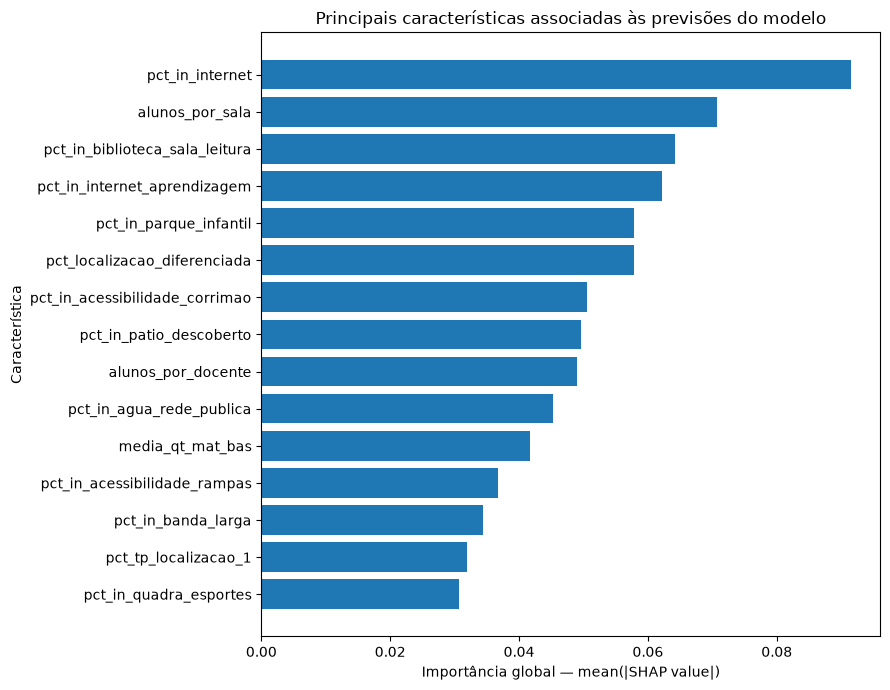

In [48]:
top_shap = (
    importancia_shap_estrategica
    .head(15)
    .sort_values(
        "importancia_shap",
        ascending=True,
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_shap["variavel"],
    top_shap["importancia_shap"],
)

plt.xlabel("Importância global — mean(|SHAP value|)")
plt.ylabel("Característica")
plt.title(
    "Principais características associadas às previsões do modelo"
)

plt.tight_layout()
plt.show()

### 7.3 Direção das associações

A importância global apresentada anteriormente indica quais características possuem maior contribuição para as previsões do modelo, mas não determina, isoladamente, a direção dessa associação.

Para complementar a análise, são considerados os resultados de interpretabilidade produzidos na etapa de modelagem, especialmente os gráficos de Partial Dependence e a distribuição dos valores SHAP.

Essas técnicas permitem avaliar como diferentes valores das características se relacionam com as previsões do modelo. Valores SHAP positivos indicam contribuição para aumentar a saída prevista pelo modelo, enquanto valores negativos indicam contribuição em sentido oposto.

Como a classe positiva do modelo corresponde à **não alfabetização**, contribuições positivas representam aumento da previsão de risco de não alfabetização e contribuições negativas representam redução dessa previsão.

As relações identificadas representam o comportamento preditivo aprendido pelo modelo e não devem ser interpretadas como efeitos causais das características sobre a alfabetização.

In [49]:
top_direcao_shap = (
    importancia_shap_estrategica
    .head(15)
    [
        [
            "posicao",
            "variavel",
            "importancia_shap",
            "correlacao_feature_shap",
        ]
    ]
    .copy()
)

top_direcao_shap["direcao"] = np.select(
    [
        top_direcao_shap["correlacao_feature_shap"] > 0,
        top_direcao_shap["correlacao_feature_shap"] < 0,
    ],
    [
        "Valores maiores → maior risco previsto",
        "Valores maiores → menor risco previsto",
    ],
    default="Sem direção monotônica identificada",
)

top_direcao_shap

,posicao,variavel,importancia_shap,correlacao_feature_shap,direcao
0,1,pct_in_internet,0.0915,-0.7675,Valores maiores → menor risco previsto
1,2,alunos_por_sala,0.0707,0.8119,Valores maiores → maior risco previsto
2,3,pct_in_biblioteca_sala_leitura,0.0642,-0.8043,Valores maiores → menor risco previsto
3,4,pct_in_internet_aprendizagem,0.0622,-0.7956,Valores maiores → menor risco previsto
4,5,pct_in_parque_infantil,0.0579,-0.8819,Valores maiores → menor risco previsto
5,6,pct_localizacao_diferenciada,0.0578,0.8139,Valores maiores → maior risco previsto
6,7,pct_in_acessibilidade_corrimao,0.0506,-0.7939,Valores maiores → menor risco previsto
7,8,pct_in_patio_descoberto,0.0496,0.6619,Valores maiores → maior risco previsto
8,9,alunos_por_docente,0.0490,0.6636,Valores maiores → maior risco previsto
9,10,pct_in_agua_rede_publica,0.0453,0.7928,Valores maiores → maior risco previsto


#### Interpretação

A análise SHAP mostra que as características mais relevantes para as previsões do modelo apresentam comportamentos distintos em relação ao risco estimado de não alfabetização.

Entre as características de maior importância global, maiores valores de `pct_in_internet`, `pct_in_biblioteca_sala_leitura`, `pct_in_internet_aprendizagem` e `pct_in_parque_infantil` estão associados a contribuições menores para a previsão de não alfabetização.

Em sentido oposto, maiores valores de `alunos_por_sala` estão associados a contribuições maiores para o risco previsto pelo modelo.

Algumas características apresentam associações que não devem ser interpretadas isoladamente. Por exemplo, `pct_in_agua_rede_publica` e `pct_in_banda_larga` apresentam associação positiva entre seus valores e as contribuições SHAP. Esse comportamento pode refletir relações multivariadas, interações e padrões presentes nos dados utilizados pelo modelo.

Portanto, os resultados permitem identificar quais características possuem maior influência nas previsões e a direção predominante de sua contribuição, mas não permitem estabelecer relações causais entre infraestrutura educacional e alfabetização.

#### 7.3.1 Convergência das técnicas de interpretabilidade

A interpretação do modelo foi realizada por meio de técnicas complementares. A Permutation Importance foi utilizada para avaliar a relevância global das características, os gráficos de Partial Dependence para investigar o comportamento das previsões em função de características selecionadas e o SHAP para quantificar a contribuição das características para as previsões do modelo.

Nesta etapa, os resultados dessas técnicas são analisados de forma conjunta. O objetivo não é repetir os cálculos realizados na etapa de modelagem, mas verificar se diferentes métodos de interpretabilidade fornecem evidências consistentes sobre os padrões aprendidos pelo modelo.

A convergência entre os métodos aumenta a confiança na interpretação do comportamento preditivo. Eventuais divergências também são relevantes, pois podem indicar relações não lineares, interações entre características ou diferenças entre as propriedades avaliadas por cada técnica.

As interpretações permanecem associativas e descrevem o comportamento do modelo, não constituindo evidência de relações causais.

In [50]:
from pathlib import Path

ARQUIVO_PERMUTATION = Path(
    "../data/processed/importancia_permutation_modelo_final.parquet"
)

importancia_permutation_estrategica = pd.read_parquet(
    ARQUIVO_PERMUTATION
)

print(
    "Características carregadas — Permutation Importance:",
    len(importancia_permutation_estrategica),
)

display(
    importancia_permutation_estrategica.head(15)
)

Características carregadas — Permutation Importance: 36


,variavel,importancia_media,desvio_padrao,posicao
0,alunos_por_sala,0.0115,0.0002,1
1,pct_in_agua_rede_publica,0.0113,0.0000,2
2,pct_in_parque_infantil,0.0100,0.0008,3
3,pct_tp_localizacao_1,0.0097,0.0005,4
4,pct_in_biblioteca_sala_leitura,0.0089,0.0007,5
5,pct_in_internet_aprendizagem,0.0083,0.0009,6
6,pct_in_internet,0.0082,0.0004,7
7,alunos_por_docente,0.0081,0.0002,8
8,pct_in_acessibilidade_corrimao,0.0080,0.0006,9
9,media_qt_salas_utilizadas,0.0073,0.0002,10


In [51]:
comparacao_importancias = (
    importancia_shap_estrategica[
        [
            "variavel",
            "posicao",
            "importancia_shap",
        ]
    ]
    .rename(
        columns={
            "posicao": "posicao_shap",
        }
    )
    .merge(
        importancia_permutation_estrategica[
            [
                "variavel",
                "posicao",
                "importancia_media",
            ]
        ].rename(
            columns={
                "posicao": "posicao_permutation",
                "importancia_media": "importancia_permutation",
            }
        ),
        on="variavel",
        how="inner",
    )
)

comparacao_importancias["diferenca_posicoes"] = (
    comparacao_importancias["posicao_shap"]
    - comparacao_importancias["posicao_permutation"]
).abs()

comparacao_importancias = (
    comparacao_importancias
    .sort_values("posicao_shap")
    .reset_index(drop=True)
)

display(
    comparacao_importancias.head(15)
)

,variavel,posicao_shap,importancia_shap,posicao_permutation,importancia_permutation,diferenca_posicoes
0,pct_in_internet,1,0.0915,7,0.0082,6
1,alunos_por_sala,2,0.0707,1,0.0115,1
2,pct_in_biblioteca_sala_leitura,3,0.0642,5,0.0089,2
3,pct_in_internet_aprendizagem,4,0.0622,6,0.0083,2
4,pct_in_parque_infantil,5,0.0579,3,0.0100,2
5,pct_localizacao_diferenciada,6,0.0578,11,0.0072,5
6,pct_in_acessibilidade_corrimao,7,0.0506,9,0.0080,2
7,pct_in_patio_descoberto,8,0.0496,12,0.0062,4
8,alunos_por_docente,9,0.0490,8,0.0081,1
9,pct_in_agua_rede_publica,10,0.0453,2,0.0113,8


#### 7.3.2 Concordância entre SHAP e Permutation Importance

A concordância entre os rankings produzidos pelo SHAP e pela Permutation Importance é avaliada quantitativamente.

A correlação de Spearman é utilizada para verificar a similaridade da ordenação global das características, enquanto a sobreposição entre os grupos de maior importância permite avaliar se os métodos identificam conjuntos semelhantes de variáveis prioritárias.

Como as técnicas medem propriedades diferentes do comportamento do modelo, não se espera correspondência perfeita entre as posições dos rankings.

In [52]:
from scipy.stats import spearmanr

correlacao_rank, p_valor_rank = spearmanr(
    comparacao_importancias["posicao_shap"],
    comparacao_importancias["posicao_permutation"],
)

top_10_shap = set(
    comparacao_importancias
    .nsmallest(10, "posicao_shap")["variavel"]
)

top_10_permutation = set(
    comparacao_importancias
    .nsmallest(10, "posicao_permutation")["variavel"]
)

top_15_shap = set(
    comparacao_importancias
    .nsmallest(15, "posicao_shap")["variavel"]
)

top_15_permutation = set(
    comparacao_importancias
    .nsmallest(15, "posicao_permutation")["variavel"]
)

sobreposicao_top10 = top_10_shap & top_10_permutation
sobreposicao_top15 = top_15_shap & top_15_permutation

print(f"Correlação de Spearman dos rankings: {correlacao_rank:.4f}")
print(f"p-valor: {p_valor_rank:.6f}")

print(
    f"\nSobreposição Top 10: "
    f"{len(sobreposicao_top10)}/10 "
    f"({len(sobreposicao_top10) / 10 * 100:.1f}%)"
)

print(
    f"Sobreposição Top 15: "
    f"{len(sobreposicao_top15)}/15 "
    f"({len(sobreposicao_top15) / 15 * 100:.1f}%)"
)

print("\nCaracterísticas em comum no Top 10:")
for variavel in sorted(sobreposicao_top10):
    print(f"- {variavel}")

Correlação de Spearman dos rankings: 0.8905
p-valor: 0.000000

Sobreposição Top 10: 8/10 (80.0%)
Sobreposição Top 15: 13/15 (86.7%)

Características em comum no Top 10:
- alunos_por_docente
- alunos_por_sala
- pct_in_acessibilidade_corrimao
- pct_in_agua_rede_publica
- pct_in_biblioteca_sala_leitura
- pct_in_internet
- pct_in_internet_aprendizagem
- pct_in_parque_infantil


#### 7.3.3 Validação com Partial Dependence

Como complemento às medidas globais de importância e às contribuições identificadas pelo SHAP, são utilizados os resultados de Partial Dependence calculados durante a etapa de modelagem.

A análise é restrita às três características previamente selecionadas no notebook de modelagem: `alunos_por_sala`, `pct_in_agua_rede_publica` e `pct_in_parque_infantil`.

O objetivo é verificar a forma da relação aprendida pelo modelo para essas características e confrontá-la com a direção predominante identificada pelo SHAP, sem recalcular os modelos ou os resultados de interpretabilidade.

In [53]:
from pathlib import Path

ARQUIVO_PDP = Path(
    "../data/processed/partial_dependence_modelo_final.parquet"
)

pdp_estrategico = pd.read_parquet(
    ARQUIVO_PDP
)

print(f"Pontos carregados: {len(pdp_estrategico):,}")
print(
    "Características analisadas:",
    pdp_estrategico["variavel"].nunique(),
)

display(
    pdp_estrategico
    .groupby("variavel")
    .agg(
        pontos=("valor_feature", "size"),
        valor_min=("valor_feature", "min"),
        valor_max=("valor_feature", "max"),
        pd_min=("partial_dependence", "min"),
        pd_max=("partial_dependence", "max"),
    )
)

Pontos carregados: 300
Características analisadas: 3


,pontos,valor_min,valor_max,pd_min,pd_max
variavel,,,,,
alunos_por_sala,100,20.4516,48.7253,0.3745,0.4338
pct_in_agua_rede_publica,100,21.7949,100.0000,0.3936,0.4359
pct_in_parque_infantil,100,0.0000,94.3662,0.3742,0.4316


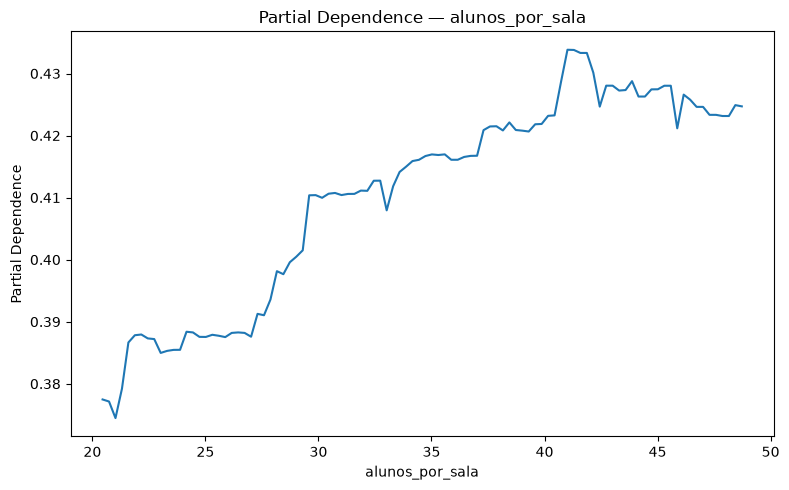

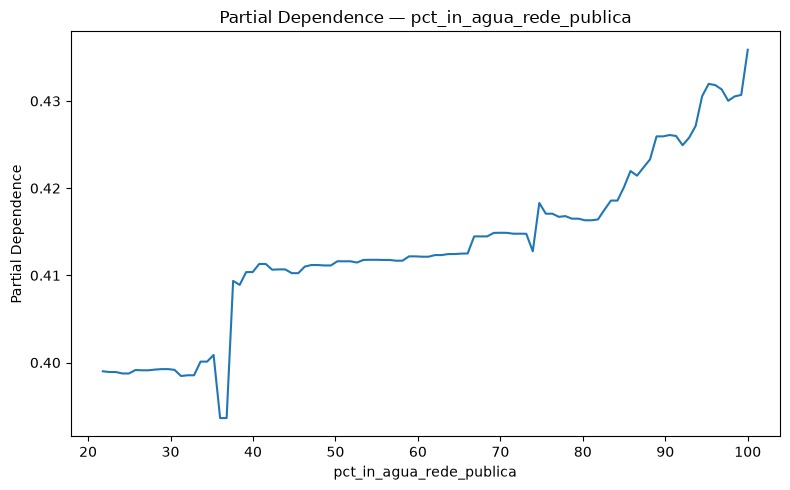

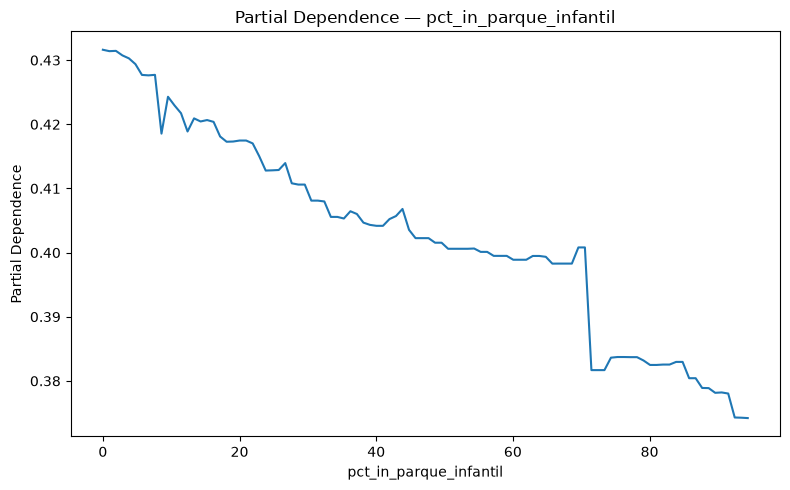

In [54]:
variaveis_pdp = pdp_estrategico["variavel"].unique()

for variavel in variaveis_pdp:
    dados_pdp = (
        pdp_estrategico[
            pdp_estrategico["variavel"] == variavel
        ]
        .sort_values("valor_feature")
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        dados_pdp["valor_feature"],
        dados_pdp["partial_dependence"],
    )

    plt.xlabel(variavel)
    plt.ylabel("Partial Dependence")
    plt.title(
        f"Partial Dependence — {variavel}"
    )

    plt.tight_layout()
    plt.show()

In [55]:
variaveis_pdp = [
    "alunos_por_sala",
    "pct_in_agua_rede_publica",
    "pct_in_parque_infantil",
]

comparacao_shap_pdp = (
    importancia_shap_estrategica[
        importancia_shap_estrategica["variavel"].isin(variaveis_pdp)
    ][
        [
            "variavel",
            "importancia_shap",
            "correlacao_feature_shap",
        ]
    ]
    .copy()
)

comparacao_shap_pdp["direcao_shap"] = np.select(
    [
        comparacao_shap_pdp["correlacao_feature_shap"] > 0,
        comparacao_shap_pdp["correlacao_feature_shap"] < 0,
    ],
    [
        "Maior valor → maior risco previsto",
        "Maior valor → menor risco previsto",
    ],
    default="Sem direção monotônica identificada",
)

display(
    comparacao_shap_pdp
    .sort_values("importancia_shap", ascending=False)
)

,variavel,importancia_shap,correlacao_feature_shap,direcao_shap
1,alunos_por_sala,0.0707,0.8119,Maior valor → maior risco previsto
4,pct_in_parque_infantil,0.0579,-0.8819,Maior valor → menor risco previsto
9,pct_in_agua_rede_publica,0.0453,0.7928,Maior valor → maior risco previsto


#### 7.3.4 Síntese da interpretabilidade

As diferentes técnicas de interpretabilidade apresentam resultados convergentes, embora avaliem aspectos distintos do comportamento do modelo.

A comparação entre SHAP e Permutation Importance apresentou correlação de Spearman de **0,8905** entre os rankings das características. Além disso, **8 das 10 características (80,0%)** e **13 das 15 características (86,7%)** de maior importância são comuns às duas técnicas. Esses resultados indicam elevada concordância na identificação das características mais relevantes para as previsões.

A análise de Partial Dependence complementa esse resultado ao avaliar a forma das relações aprendidas pelo modelo para três características previamente selecionadas. `alunos_por_sala` e `pct_in_agua_rede_publica` apresentam relações predominantemente crescentes com o risco previsto, enquanto `pct_in_parque_infantil` apresenta relação predominantemente decrescente.

Essas direções são consistentes com os resultados do SHAP: `alunos_por_sala` e `pct_in_agua_rede_publica` apresentam associação positiva com o risco previsto, enquanto `pct_in_parque_infantil` apresenta associação negativa.

Assim, as três técnicas fornecem evidências complementares: a Permutation Importance identifica características relevantes para o desempenho preditivo, o SHAP permite analisar sua contribuição e direção predominante nas previsões e o Partial Dependence evidencia a forma das relações aprendidas pelo modelo nas características selecionadas.

Os resultados devem ser interpretados como associações presentes no comportamento preditivo do modelo e **não como evidência de relações causais** entre as características educacionais e a alfabetização.

### 7.4 Implicações estratégicas dos fatores associados ao risco

Os resultados de interpretabilidade são utilizados nesta seção para traduzir o comportamento preditivo do modelo em informações úteis ao planejamento educacional.

A análise considera conjuntamente a relevância das características, a direção predominante de suas associações com o risco previsto e, quando disponível, a forma das relações identificadas pelo Partial Dependence.

O objetivo não é estabelecer relações causais ou recomendar intervenções automaticamente, mas identificar características associadas a diferentes níveis de risco que possam apoiar diagnósticos, priorização de análises e formulação de hipóteses para políticas educacionais.

#### 7.4.1 Características associadas a maior risco previsto

A partir dos resultados de SHAP, são identificadas entre as características de maior importância aquelas cujos valores mais elevados apresentam associação predominante com maior risco previsto de não alfabetização.

A seleção combina a importância global da característica com a direção da associação identificada pelo SHAP. Essa classificação descreve o comportamento aprendido pelo modelo e não implica relação causal.

In [56]:
top_15_shap_direcao = (
    importancia_shap_estrategica
    .nsmallest(15, "posicao")
    .copy()
)

maior_risco_shap = (
    top_15_shap_direcao[
        top_15_shap_direcao["correlacao_feature_shap"] > 0
    ]
    [
        [
            "posicao",
            "variavel",
            "importancia_shap",
            "correlacao_feature_shap",
        ]
    ]
    .sort_values("posicao")
    .reset_index(drop=True)
)

maior_risco_shap["direcao"] = (
    "Valores maiores → maior risco previsto"
)

display(maior_risco_shap)

,posicao,variavel,importancia_shap,correlacao_feature_shap,direcao
0,2,alunos_por_sala,0.0707,0.8119,Valores maiores → maior risco previsto
1,6,pct_localizacao_diferenciada,0.0578,0.8139,Valores maiores → maior risco previsto
2,8,pct_in_patio_descoberto,0.0496,0.6619,Valores maiores → maior risco previsto
3,9,alunos_por_docente,0.0490,0.6636,Valores maiores → maior risco previsto
4,10,pct_in_agua_rede_publica,0.0453,0.7928,Valores maiores → maior risco previsto
5,11,media_qt_mat_bas,0.0417,0.8037,Valores maiores → maior risco previsto
6,13,pct_in_banda_larga,0.0343,0.7932,Valores maiores → maior risco previsto


Entre as 15 características de maior importância global segundo o SHAP, sete apresentam associação predominantemente positiva com o risco previsto de não alfabetização.

`alunos_por_sala` destaca-se como a característica de maior importância desse grupo e apresenta forte associação positiva com a contribuição SHAP. `alunos_por_docente` apresenta comportamento na mesma direção, indicando que valores mais elevados dessas características estão associados, no comportamento do modelo, a maior risco previsto.

Também apresentam associação positiva `pct_localizacao_diferenciada`, `pct_in_patio_descoberto`, `pct_in_agua_rede_publica`, `media_qt_mat_bas` e `pct_in_banda_larga`.

Algumas dessas associações não possuem interpretação substantiva direta ou intuitiva quando consideradas isoladamente. Isso é compatível com um modelo preditivo construído a partir de características contextuais potencialmente correlacionadas: uma característica pode funcionar como marcador de determinados contextos educacionais sem representar a causa do risco identificado.

Portanto, os resultados desta subseção devem ser utilizados para identificar padrões que merecem investigação e não para concluir que o aumento ou a redução isolada dessas características produziria alteração no nível de alfabetização.

#### 7.4.2 Características associadas a menor risco previsto

De forma complementar, são identificadas entre as 15 características de maior importância global segundo o SHAP aquelas cujos valores mais elevados apresentam associação predominante com menor risco previsto de não alfabetização.

A seleção utiliza o mesmo critério da análise anterior, combinando importância global e direção da associação identificada pelo SHAP. Novamente, os resultados descrevem o comportamento preditivo do modelo e não representam efeitos causais.

In [57]:
menor_risco_shap = (
    top_15_shap_direcao[
        top_15_shap_direcao["correlacao_feature_shap"] < 0
    ]
    [
        [
            "posicao",
            "variavel",
            "importancia_shap",
            "correlacao_feature_shap",
        ]
    ]
    .sort_values("posicao")
    .reset_index(drop=True)
)

menor_risco_shap["direcao"] = (
    "Valores maiores → menor risco previsto"
)

display(menor_risco_shap)

,posicao,variavel,importancia_shap,correlacao_feature_shap,direcao
0,1,pct_in_internet,0.0915,-0.7675,Valores maiores → menor risco previsto
1,3,pct_in_biblioteca_sala_leitura,0.0642,-0.8043,Valores maiores → menor risco previsto
2,4,pct_in_internet_aprendizagem,0.0622,-0.7956,Valores maiores → menor risco previsto
3,5,pct_in_parque_infantil,0.0579,-0.8819,Valores maiores → menor risco previsto
4,7,pct_in_acessibilidade_corrimao,0.0506,-0.7939,Valores maiores → menor risco previsto
5,12,pct_in_acessibilidade_rampas,0.0367,-0.7334,Valores maiores → menor risco previsto
6,14,pct_tp_localizacao_1,0.0319,-0.1269,Valores maiores → menor risco previsto
7,15,pct_in_quadra_esportes,0.0307,-0.7274,Valores maiores → menor risco previsto


Entre as 15 características de maior importância global segundo o SHAP, oito apresentam associação predominantemente negativa com o risco previsto de não alfabetização.

`pct_in_internet`, característica de maior importância global segundo o SHAP, apresenta associação negativa com o risco previsto. O mesmo comportamento é observado para `pct_in_internet_aprendizagem`, indicando que valores mais elevados dessas características estão associados, no comportamento do modelo, a menor risco previsto.

Também apresentam associação negativa `pct_in_biblioteca_sala_leitura`, `pct_in_parque_infantil`, `pct_in_acessibilidade_corrimao`, `pct_in_acessibilidade_rampas` e `pct_in_quadra_esportes`. `pct_tp_localizacao_1` também apresenta associação direcional negativa, embora substancialmente mais fraca que as demais características destacadas.

Parte relevante dessas características está relacionada à disponibilidade de infraestrutura, conectividade, acessibilidade e recursos do ambiente escolar. Esse padrão sugere que diferentes condições estruturais das redes de ensino estão associadas às previsões produzidas pelo modelo.

Esses resultados não permitem concluir que a presença ou ampliação isolada desses recursos provoque redução do risco de não alfabetização. As características podem representar contextos educacionais mais amplos e apresentar relações entre si e com outras condições não observadas diretamente pelo modelo.

#### 7.4.3 Investigação das associações contraintuitivas

A análise de interpretabilidade identificou duas relações que exigem investigação adicional antes de serem utilizadas na leitura estratégica do modelo.

Maiores valores de `pct_in_agua_rede_publica` e `pct_in_banda_larga` apresentam associação positiva com o risco previsto de não alfabetização. Embora essas relações descrevam o comportamento aprendido pelo modelo, sua interpretação substantiva isolada seria contraintuitiva.

Uma hipótese é que essas características estejam funcionando como marcadores de outros aspectos do contexto municipal, especialmente localização urbana/rural e porte da rede educacional. Nesse caso, a associação identificada pelo modelo poderia refletir efeitos de composição presentes nos dados, e não um efeito adverso da disponibilidade de água de rede pública ou banda larga.

A investigação é realizada em três etapas:

1. associação das características contraintuitivas com urbanização e porte municipal;
2. relação dessas características com a taxa observada de não alfabetização;
3. persistência das associações após considerar diferenças de urbanização e porte.

O objetivo é compreender melhor o padrão encontrado, sem estabelecer relações causais.

##### 7.4.3.1 Construção da base de diagnóstico

A investigação é realizada no nível municipal, mantendo a mesma granularidade utilizada nas análises estratégicas anteriores.

Além das duas características contraintuitivas, são considerados:

- `pct_tp_localizacao_1`, como indicador do perfil de localização das escolas;
- quantidade de alunos avaliados;
- quantidade de escolas;
- risco médio previsto;
- taxa observada de não alfabetização.

As quantidades de alunos e escolas são utilizadas apenas como indicadores de porte para esta análise diagnóstica.

In [58]:
variaveis_contexto_diagnostico = [
    "id_municipio",
    "id_municipio_nome",
    "pct_in_agua_rede_publica",
    "pct_in_banda_larga",
    "pct_tp_localizacao_1",
]

contexto_diagnostico = (
    base_cluster_municipio[
        variaveis_contexto_diagnostico
    ]
    .copy()
)

diagnostico_contraintuitivos = (
    contexto_diagnostico
    .merge(
        validacao_municipal[
            [
                "id_municipio",
                "alunos_avaliados",
                "escolas",
                "risco_medio",
                "taxa_nao_alfabetizado_observada",
            ]
        ],
        on="id_municipio",
        how="inner",
        validate="one_to_one",
    )
)

print(
    f"Municípios analisados: "
    f"{len(diagnostico_contraintuitivos):,}"
)

print("\nValores ausentes:")
display(
    diagnostico_contraintuitivos
    .isna()
    .sum()
    .to_frame("nulos")
)

diagnostico_contraintuitivos.head()

Municípios analisados: 4,973

Valores ausentes:


,nulos
id_municipio,0
id_municipio_nome,0
pct_in_agua_rede_publica,0
pct_in_banda_larga,0
pct_tp_localizacao_1,0
alunos_avaliados,0
escolas,0
risco_medio,0
taxa_nao_alfabetizado_observada,0


,id_municipio,id_municipio_nome,pct_in_agua_rede_publica,pct_in_banda_larga,pct_tp_localizacao_1,alunos_avaliados,escolas,risco_medio,taxa_nao_alfabetizado_observada
0,1100015,Alta Floresta D'Oeste,28.5714,42.8571,71.4286,275,8,0.2449,0.3200
1,1100023,Ariquemes,81.4815,81.4815,74.0741,1066,18,0.3453,0.3415
2,1100031,Cabixi,75.0000,50.0000,100.0000,75,2,0.4004,0.2400
3,1100049,Cacoal,61.4294,74.3066,62.1381,951,19,0.3603,0.3365
4,1100056,Cerejeiras,71.4286,0.0000,100.0000,244,4,0.2982,0.3320


##### 7.4.3.2 Associação com urbanização e porte

Inicialmente, é avaliada a associação monotônica das duas características contraintuitivas com variáveis que representam diferenças de contexto municipal.

A correlação de Spearman é utilizada por não exigir relações lineares e por ser consistente com as análises de associação adotadas nas demais etapas do projeto.

Valores elevados de correlação com localização ou porte indicariam que as características podem estar representando dimensões contextuais mais amplas, o que exigiria cautela em sua interpretação isolada.

In [59]:
variaveis_diagnostico = [
    "pct_in_agua_rede_publica",
    "pct_in_banda_larga",
    "pct_tp_localizacao_1",
    "alunos_avaliados",
    "escolas",
    "risco_medio",
    "taxa_nao_alfabetizado_observada",
]

correlacoes_diagnostico = (
    diagnostico_contraintuitivos[
        variaveis_diagnostico
    ]
    .corr(method="spearman")
)

display(
    correlacoes_diagnostico.loc[
        [
            "pct_in_agua_rede_publica",
            "pct_in_banda_larga",
        ],
        [
            "pct_tp_localizacao_1",
            "alunos_avaliados",
            "escolas",
            "risco_medio",
            "taxa_nao_alfabetizado_observada",
        ],
    ].round(4)
)

,pct_tp_localizacao_1,alunos_avaliados,escolas,risco_medio,taxa_nao_alfabetizado_observada
pct_in_agua_rede_publica,0.7180,-0.1018,-0.1797,-0.3142,-0.1665
pct_in_banda_larga,0.2943,-0.0834,-0.1447,-0.0626,-0.1015


##### 7.4.3.3 Associação dentro de níveis semelhantes de localização

Uma associação agregada pode ser influenciada pela composição dos municípios analisados. Para avaliar essa possibilidade, os municípios são divididos em estratos segundo pct_tp_localizacao_1. Como a variável apresenta valores repetidos, os pontos de corte coincidentes são consolidados automaticamente.

Em seguida, a associação entre as características contraintuitivas e a taxa observada de não alfabetização é recalculada dentro de cada grupo.

Se a associação positiva observada no conjunto completo enfraquecer, desaparecer ou inverter dentro dos estratos, isso constitui evidência de que diferenças de contexto territorial contribuem para o padrão agregado.

In [60]:
base_urbanizacao = (
    diagnostico_contraintuitivos
    .dropna(
        subset=[
            "pct_tp_localizacao_1",
            "pct_in_agua_rede_publica",
            "pct_in_banda_larga",
            "taxa_nao_alfabetizado_observada",
        ]
    )
    .copy()
)

base_urbanizacao["quintil_localizacao"] = pd.qcut(
    base_urbanizacao["pct_tp_localizacao_1"],
    q=5,
    duplicates="drop",
)

resumo_localizacao = (
    base_urbanizacao
    .groupby(
        "quintil_localizacao",
        observed=True,
    )
    .agg(
        municipios=("id_municipio", "size"),
        localizacao_media=(
            "pct_tp_localizacao_1",
            "mean",
        ),
        agua_rede_media=(
            "pct_in_agua_rede_publica",
            "mean",
        ),
        banda_larga_media=(
            "pct_in_banda_larga",
            "mean",
        ),
        nao_alfabetizacao_media=(
            "taxa_nao_alfabetizado_observada",
            "mean",
        ),
    )
    .reset_index()
)

display(resumo_localizacao.round(4))

,quintil_localizacao,municipios,localizacao_media,agua_rede_media,banda_larga_media,nao_alfabetizacao_media
0,"(-0.001, 33.333]",1016,22.6308,48.1921,72.7206,0.4501
1,"(33.333, 54.035]",973,44.1945,64.0029,77.2852,0.3893
2,"(54.035, 75.0]",997,65.0975,76.2485,83.5069,0.3627
3,"(75.0, 100.0]",1987,93.9576,94.3959,88.4757,0.3252


In [61]:
correlacoes_por_localizacao = []

for quintil, dados in base_urbanizacao.groupby(
    "quintil_localizacao",
    observed=True,
):
    correlacao_agua = (
        dados[
            [
                "pct_in_agua_rede_publica",
                "taxa_nao_alfabetizado_observada",
            ]
        ]
        .corr(method="spearman")
        .iloc[0, 1]
    )

    correlacao_banda = (
        dados[
            [
                "pct_in_banda_larga",
                "taxa_nao_alfabetizado_observada",
            ]
        ]
        .corr(method="spearman")
        .iloc[0, 1]
    )

    correlacoes_por_localizacao.append(
        {
            "quintil_localizacao": str(quintil),
            "municipios": len(dados),
            "corr_agua_observado": correlacao_agua,
            "corr_banda_observado": correlacao_banda,
        }
    )

correlacoes_por_localizacao = pd.DataFrame(
    correlacoes_por_localizacao
)

display(
    correlacoes_por_localizacao.round(4)
)

,quintil_localizacao,municipios,corr_agua_observado,corr_banda_observado
0,"(-0.001, 33.333]",1016,0.0996,-0.0253
1,"(33.333, 54.035]",973,0.1051,0.0377
2,"(54.035, 75.0]",997,-0.0618,-0.0842
3,"(75.0, 100.0]",1987,-0.1614,-0.0807


##### 7.4.3.4 Verificação por porte municipal

Como o número de alunos e de escolas varia substancialmente entre os municípios, também é avaliada a possibilidade de o porte da rede contribuir para as associações agregadas.

Os municípios são divididos em quintis segundo o número de alunos avaliados e as associações com a taxa observada são novamente calculadas dentro de cada estrato.

In [62]:
base_porte = (
    diagnostico_contraintuitivos
    .dropna(
        subset=[
            "alunos_avaliados",
            "pct_in_agua_rede_publica",
            "pct_in_banda_larga",
            "taxa_nao_alfabetizado_observada",
        ]
    )
    .copy()
)

base_porte["quintil_porte"] = pd.qcut(
    base_porte["alunos_avaliados"],
    q=5,
    duplicates="drop",
)

resumo_porte = (
    base_porte
    .groupby(
        "quintil_porte",
        observed=True,
    )
    .agg(
        municipios=("id_municipio", "size"),
        alunos_medios=("alunos_avaliados", "mean"),
        escolas_medias=("escolas", "mean"),
        agua_rede_media=(
            "pct_in_agua_rede_publica",
            "mean",
        ),
        banda_larga_media=(
            "pct_in_banda_larga",
            "mean",
        ),
        nao_alfabetizacao_media=(
            "taxa_nao_alfabetizado_observada",
            "mean",
        ),
    )
    .reset_index()
)

display(resumo_porte.round(4))

,quintil_porte,municipios,alunos_medios,escolas_medias,agua_rede_media,banda_larga_media,nao_alfabetizacao_media
0,"(29.999, 59.0]",1037,44.0395,1.5699,80.0224,80.1936,0.3420
1,"(59.0, 97.0]",976,77.3627,2.4406,75.1944,81.0339,0.3521
2,"(97.0, 170.0]",978,130.5757,4.0644,72.5330,80.4601,0.3747
3,"(170.0, 342.0]",988,238.5638,7.0810,70.5618,81.7792,0.3854
4,"(342.0, 94373.0]",994,1364.0674,26.9085,78.2667,86.9239,0.4009


In [63]:
correlacoes_por_porte = []

for quintil, dados in base_porte.groupby(
    "quintil_porte",
    observed=True,
):
    correlacao_agua = (
        dados[
            [
                "pct_in_agua_rede_publica",
                "taxa_nao_alfabetizado_observada",
            ]
        ]
        .corr(method="spearman")
        .iloc[0, 1]
    )

    correlacao_banda = (
        dados[
            [
                "pct_in_banda_larga",
                "taxa_nao_alfabetizado_observada",
            ]
        ]
        .corr(method="spearman")
        .iloc[0, 1]
    )

    correlacoes_por_porte.append(
        {
            "quintil_porte": str(quintil),
            "municipios": len(dados),
            "corr_agua_observado": correlacao_agua,
            "corr_banda_observado": correlacao_banda,
        }
    )

correlacoes_por_porte = pd.DataFrame(
    correlacoes_por_porte
)

display(
    correlacoes_por_porte.round(4)
)

,quintil_porte,municipios,corr_agua_observado,corr_banda_observado
0,"(29.999, 59.0]",1037,-0.2061,-0.0886
1,"(59.0, 97.0]",976,-0.0851,-0.0636
2,"(97.0, 170.0]",978,-0.1393,-0.0841
3,"(170.0, 342.0]",988,-0.1739,-0.1029
4,"(342.0, 94373.0]",994,-0.1541,-0.1513


##### 7.4.3.5 Associação parcial controlando localização e porte

Por fim, é calculada uma associação parcial de Spearman entre cada característica contraintuitiva e a taxa observada de não alfabetização, controlando simultaneamente por localização e porte municipal.

A análise é diagnóstica e não deve ser interpretada como estimativa causal. Seu objetivo é verificar quanto da associação original permanece após retirar estatisticamente a variação associada às variáveis de contexto consideradas.

In [64]:
def correlacao_parcial_spearman(
    dataframe,
    x,
    y,
    controles,
):
    colunas = [x, y] + controles

    dados = (
        dataframe[colunas]
        .dropna()
        .rank(method="average")
        .astype(float)
    )

    X_controles = dados[controles].to_numpy()

    X_controles = np.column_stack(
        [
            np.ones(len(X_controles)),
            X_controles,
        ]
    )

    x_valores = dados[x].to_numpy()
    y_valores = dados[y].to_numpy()

    beta_x = np.linalg.lstsq(
        X_controles,
        x_valores,
        rcond=None,
    )[0]

    beta_y = np.linalg.lstsq(
        X_controles,
        y_valores,
        rcond=None,
    )[0]

    residuo_x = (
        x_valores
        - X_controles @ beta_x
    )

    residuo_y = (
        y_valores
        - X_controles @ beta_y
    )

    return np.corrcoef(
        residuo_x,
        residuo_y,
    )[0, 1]

In [65]:
controles_contexto = [
    "pct_tp_localizacao_1",
    "alunos_avaliados",
    "escolas",
]

resultado_parcial = pd.DataFrame(
    {
        "variavel": [
            "pct_in_agua_rede_publica",
            "pct_in_banda_larga",
        ],
        "spearman_bruto": [
            diagnostico_contraintuitivos[
                [
                    "pct_in_agua_rede_publica",
                    "taxa_nao_alfabetizado_observada",
                ]
            ]
            .corr(method="spearman")
            .iloc[0, 1],

            diagnostico_contraintuitivos[
                [
                    "pct_in_banda_larga",
                    "taxa_nao_alfabetizado_observada",
                ]
            ]
            .corr(method="spearman")
            .iloc[0, 1],
        ],
        "spearman_parcial": [
            correlacao_parcial_spearman(
                diagnostico_contraintuitivos,
                x="pct_in_agua_rede_publica",
                y="taxa_nao_alfabetizado_observada",
                controles=controles_contexto,
            ),
            correlacao_parcial_spearman(
                diagnostico_contraintuitivos,
                x="pct_in_banda_larga",
                y="taxa_nao_alfabetizado_observada",
                controles=controles_contexto,
            ),
        ],
    }
)

resultado_parcial["variacao_abs"] = (
    resultado_parcial["spearman_parcial"].abs()
    - resultado_parcial["spearman_bruto"].abs()
)

display(
    resultado_parcial.round(4)
)

,variavel,spearman_bruto,spearman_parcial,variacao_abs
0,pct_in_agua_rede_publica,-0.1665,0.0343,-0.1322
1,pct_in_banda_larga,-0.1015,-0.0106,-0.0909


> **Sustenta H4**: a atenuação das associações após o controle por localização e porte municipal indica que parte relevante do padrão observado está associada à composição contextual dos municípios, não devendo ser interpretada isoladamente como efeito direto das variáveis de infraestrutura.

##### 7.4.3.6 Verificação da cobertura municipal

A análise diagnóstica combina a base municipal utilizada na clusterização com os indicadores de validação do modelo.

Como a junção entre essas bases considera apenas municípios presentes em ambas, é verificada a cobertura municipal antes da interpretação dos resultados, de forma a identificar eventuais diferenças no universo analisado.

In [66]:
municipios_cluster = set(
    base_cluster_municipio["id_municipio"].astype(str)
)

municipios_validacao = set(
    validacao_municipal["id_municipio"].astype(str)
)

somente_cluster = municipios_cluster - municipios_validacao
somente_validacao = municipios_validacao - municipios_cluster
em_ambas = municipios_cluster & municipios_validacao

print(f"Municípios na clusterização: {len(municipios_cluster):,}")
print(f"Municípios na validação: {len(municipios_validacao):,}")
print(f"Municípios presentes em ambas: {len(em_ambas):,}")
print(f"Somente na clusterização: {len(somente_cluster):,}")
print(f"Somente na validação: {len(somente_validacao):,}")

Municípios na clusterização: 5,517
Municípios na validação: 4,973
Municípios presentes em ambas: 4,973
Somente na clusterização: 544
Somente na validação: 0


In [67]:
municipios_excluidos = (
    base_cluster_municipio[
        base_cluster_municipio["id_municipio"]
        .astype(str)
        .isin(somente_cluster)
    ]
    [
        [
            "id_municipio",
            "id_municipio_nome",
        ]
    ]
    .copy()
    .sort_values("id_municipio")
    .reset_index(drop=True)
)

print(f"Municípios excluídos da validação: {len(municipios_excluidos):,}")

display(municipios_excluidos.head(20))

Municípios excluídos da validação: 544


,id_municipio,id_municipio_nome
0,1507466,São João da Ponta
1,1700251,Abreulândia
2,1702703,Aurora do Tocantins
3,1703602,Brasilândia do Tocantins
4,1703826,Cachoeirinha
5,1704600,Chapada de Areia
6,1706258,Crixás do Tocantins
7,1709807,Ipueiras
8,1711100,Itaporã do Tocantins
9,1712157,Lavandeira


In [68]:
municipios_abaixo_minimo = (
    risco_municipio[
        risco_municipio["alunos_avaliados"] < MIN_ALUNOS
    ]
    [
        [
            "id_municipio",
            "id_municipio_nome",
            "alunos_avaliados",
            "escolas",
        ]
    ]
    .copy()
)

print(
    "Municípios com menos de "
    f"{MIN_ALUNOS} alunos avaliados: "
    f"{len(municipios_abaixo_minimo):,}"
)

print(
    "Coincidência com os municípios ausentes da validação:",
    set(
        municipios_abaixo_minimo["id_municipio"]
        .astype(str)
    ) == somente_cluster,
)

display(
    municipios_abaixo_minimo[
        "alunos_avaliados"
    ].describe()
)

Municípios com menos de 30 alunos avaliados: 544
Coincidência com os municípios ausentes da validação: True


count   544.0000
mean     20.9375
std       5.6235
min       7.0000
25%      17.0000
50%      22.0000
75%      26.0000
max      29.0000
Name: alunos_avaliados, dtype: Float64

##### Resultado da verificação

A diferença de cobertura foi integralmente explicada pelo critério mínimo de 30 alunos avaliados adotado anteriormente para a construção do indicador municipal de risco. Os 544 municípios presentes na base de clusterização e ausentes da validação possuem menos de 30 alunos avaliados, coincidindo exatamente com os municípios excluídos por esse critério.

Assim, a análise diagnóstica dos achados contraintuitivos considera 4.973 municípios, preservando o mesmo universo utilizado na validação municipal do indicador de risco. A redução de cobertura não decorre de falha de junção ou perda não identificada de dados.

#### 7.4.3.7 Síntese da investigação

A investigação indica que as associações inicialmente contraintuitivas de pct_in_agua_rede_publica e pct_in_banda_larga com o risco previsto não devem ser interpretadas isoladamente como evidência de que maior disponibilidade desses recursos esteja associada a piores resultados educacionais.

Na análise municipal, ambas as características apresentaram associação negativa com a taxa observada de não alfabetização no conjunto completo: -0,1065 para água de rede pública e -0,1015 para banda larga. Portanto, no resultado efetivamente observado, municípios com maior presença desses recursos tendem, de forma agregada, a apresentar menor não alfabetização.

Também foi identificada forte associação entre água de rede pública e o indicador de localização (pct_tp_localizacao_1, ρ = 0,7180), enquanto a associação da banda larga com esse indicador foi mais moderada (ρ = 0,2943). Ao comparar municípios dentro de níveis semelhantes de localização, as associações com a não alfabetização tornam-se pequenas: para água, variam aproximadamente de -0,102 a 0,105; para banda larga, de -0,084 a 0,038. Esse enfraquecimento mostra que parte relevante do padrão agregado está relacionada à composição contextual dos municípios.

A análise por porte municipal reforça essa interpretação. Dentro dos estratos de número de alunos avaliados, as associações entre água de rede pública e não alfabetização são negativas em todos os grupos, variando de aproximadamente -0,206 a -0,085. Para banda larga, também permanecem negativas em todos os estratos, entre aproximadamente -0,151 e -0,064.

Finalmente, ao controlar simultaneamente localização, número de alunos avaliados e número de escolas, a associação parcial de Spearman com a taxa observada é reduzida para 0,0345 no caso da água de rede pública e -0,0106 para banda larga, valores próximos de zero. Em relação às associações brutas, isso representa redução absoluta de aproximadamente 0,1322 e 0,0909, respectivamente.

Em conjunto, os resultados sugerem que os sinais inicialmente observados na interpretação do modelo refletem principalmente estrutura de associação e composição contextual presente nos dados, e não uma relação direta em que maior cobertura de água ou banda larga implique maior risco educacional. Esses resultados devem permanecer interpretados como associações do comportamento preditivo do modelo, e não como relações causais.

#### 7.4.4 Leitura estratégica dos resultados

A análise conjunta das características mais relevantes mostra que o risco previsto de não alfabetização está associado a diferentes dimensões do contexto educacional, incluindo organização das turmas e do corpo docente, infraestrutura escolar, conectividade, acessibilidade e disponibilidade de recursos.

Entre as associações com maior risco previsto, `alunos_por_sala` e `alunos_por_docente` indicam que características relacionadas à organização e ao dimensionamento das turmas e da rede aparecem entre os elementos considerados relevantes pelo modelo. Por outro lado, diversas características relacionadas à infraestrutura escolar, como internet, biblioteca ou sala de leitura, parque infantil, acessibilidade e quadra de esportes, apresentam associação predominante com menor risco previsto.

Esses resultados permitem utilizar o modelo como instrumento de apoio ao diagnóstico. Municípios classificados com maior risco podem ser analisados conjuntamente com suas características contextuais, permitindo identificar quais dimensões os diferenciam de municípios com menor risco e direcionar análises mais detalhadas.

Entretanto, algumas características apresentam associações que não devem ser convertidas diretamente em recomendações de política pública. pct_in_agua_rede_publica e pct_in_banda_larga, por exemplo, aparecem associadas a maior risco previsto na interpretação do modelo. A investigação complementar mostrou, porém, que ambas apresentam associação negativa com a taxa observada de não alfabetização no conjunto dos municípios e que, após o controle simultâneo por localização e porte municipal, suas associações parciais com o resultado observado se aproximam de zero. Esse resultado reforça que os sinais identificados pelo modelo devem ser interpretados dentro da estrutura multivariada e contextual dos dados, e não como efeitos isolados dessas características sobre a alfabetização.

Assim, a principal aplicação estratégica não é prescrever intervenções isoladas a partir de uma característica, mas combinar a classificação de risco municipal com os padrões contextuais identificados. Essa abordagem permite priorizar municípios para diagnóstico e utilizar as características relevantes como dimensões adicionais de investigação antes da definição de ações educacionais.

#### 7.4.5 Limitações para tomada de decisão

A utilização estratégica dos resultados deve considerar algumas limitações da análise.

Primeiro, as relações identificadas pelo SHAP, pela Permutation Importance e pelo Partial Dependence descrevem o comportamento preditivo do modelo e não demonstram relações causais. Portanto, uma característica associada a maior ou menor risco previsto não deve ser interpretada isoladamente como causa desse resultado.

Além disso, as características utilizadas podem apresentar correlações entre si e representar dimensões mais amplas do contexto educacional. Dessa forma, a importância atribuída a uma variável não necessariamente representa um efeito independente das demais.

As conclusões também estão condicionadas aos dados, ao período analisado e às características disponíveis para o modelo. Aspectos relevantes para a alfabetização que não estejam representados na base não podem ser capturados pela análise.

Por essas razões, o modelo deve ser utilizado como instrumento de apoio à priorização e ao diagnóstico. Decisões sobre intervenções ou políticas educacionais devem incorporar análises complementares e conhecimento do contexto dos municípios identificados.

A investigação das associações contraintuitivas observadas para água de rede pública e banda larga ilustra essa limitação, uma vez que seus sinais no modelo não se reproduzem como relações equivalentes com o resultado educacional observado após a consideração de variáveis contextuais.

## 8. Conclusão estratégica

Este notebook integrou os resultados do modelo supervisionado, da análise territorial, da comparação com as metas de alfabetização e das técnicas de interpretabilidade para transformar as previsões em informações aplicáveis ao diagnóstico educacional.

As análises permitem responder às cinco questões estratégicas propostas no Tech Challenge.

### 8.1 Quais municípios apresentam maior risco educacional?

A agregação das previsões no nível municipal permitiu construir um indicador de risco contextual de não alfabetização e ordenar os municípios segundo a vulnerabilidade identificada pelo modelo.

A validação mostrou associação positiva entre o risco previsto e a taxa observada de não alfabetização, com correlação de Spearman de **0,5312**, indicando que municípios classificados com maior risco tendem também a apresentar piores resultados observados.

A análise de granularidade mostrou, entretanto, que as probabilidades apresentam pouca variação entre alunos de um mesmo município. Por esse motivo, o indicador deve ser interpretado como medida de **risco contextual municipal**, e não como instrumento de avaliação individual dos estudantes.

Assim, o ranking municipal pode apoiar a identificação de territórios prioritários para diagnóstico e acompanhamento educacional.

### 8.2 Quais regiões ou municípios apresentam padrões semelhantes?

A análise não supervisionada identificou **dois grandes perfis municipais** a partir das características contextuais, sem utilizar o risco previsto na formação dos grupos.

Para reduzir a influência direta da escala municipal, medidas absolutas de equipamentos foram excluídas quando estavam disponíveis medidas normalizadas correspondentes. Mesmo após essa adequação, a solução com dois clusters permaneceu como a configuração de melhor desempenho entre as avaliadas.

O Cluster 0 reuniu **3.574 municípios**, enquanto o Cluster 1 reuniu **1.943 municípios**. Posteriormente, ao comparar os grupos com os resultados educacionais, observou-se risco médio previsto de não alfabetização de aproximadamente **33,01% no Cluster 0** e **44,77% no Cluster 1**, acompanhado por diferença semelhante na taxa observada de não alfabetização.

A separação entre os grupos é limitada, conforme indicado pelo silhouette de **0,1882**, portanto os clusters não representam categorias rígidas. Ainda assim, permitem reconhecer perfis contextuais distintos e complementar o ranking de risco com uma visão estrutural dos municípios.

### 8.3 Como prever municípios que podem não atingir metas futuras?

A análise demonstrou que a probabilidade produzida pelo modelo não deve ser convertida diretamente em uma previsão da taxa futura de alfabetização. A formulação exploratória inicialmente testada não apresentou o comportamento esperado e, por isso, foi rejeitada.

A abordagem final combina duas dimensões distintas: o **risco contextual estimado pelo modelo** e o **desafio necessário para que o município avance de sua taxa observada de alfabetização em 2024 até a meta estabelecida para 2025**.

A baixa associação entre essas dimensões, com correlação de Spearman de **0,1377**, mostra que elas fornecem informações complementares. Um município pode apresentar risco contextual elevado sem necessariamente possuir o maior desafio de meta, e o inverso também pode ocorrer.

A combinação das duas dimensões identificou **1.377 municípios simultaneamente classificados com alto risco contextual e alto desafio frente à meta de 2025**, constituindo um grupo prioritário para acompanhamento.

Portanto, a análise não deve ser interpretada como previsão determinística do cumprimento futuro das metas, mas como um instrumento de **priorização municipal frente às metas educacionais**.

### 8.4 Quais variáveis possuem maior influência nos modelos?

A influência das características foi analisada por técnicas complementares de interpretabilidade.

O SHAP permitiu identificar a importância global e a direção predominante das contribuições das características. A Permutation Importance avaliou quanto o desempenho preditivo depende de cada variável, enquanto o Partial Dependence permitiu observar a forma das relações aprendidas pelo modelo para características selecionadas.

Os resultados apresentaram elevada convergência. Os rankings de SHAP e Permutation Importance tiveram correlação de Spearman de **0,8905**, com **80,0% de sobreposição entre as 10 características mais importantes** e **86,7% entre as 15 mais importantes**.

Para as três características analisadas também por Partial Dependence, a direção observada foi consistente com o SHAP.

Essa convergência indica que a identificação das características mais relevantes não depende exclusivamente de uma única técnica de interpretabilidade, aumentando a robustez da leitura do comportamento do modelo.

### 8.5 Quais fatores mais impactam a alfabetização?

A interpretação das características mais relevantes mostra que as previsões estão associadas a diferentes dimensões do contexto educacional.

Entre as características associadas predominantemente a maior risco previsto aparecem fatores relacionados à organização da rede e das turmas, como `alunos_por_sala` e `alunos_por_docente`, além de outras características contextuais.

Em sentido oposto, diversas características relacionadas à infraestrutura e aos recursos escolares — incluindo internet, biblioteca ou sala de leitura, parque infantil, acessibilidade e quadra de esportes — apresentam associação predominante com menor risco previsto.

Algumas associações identificadas pelo modelo exigem interpretação contextual. Em particular, água de rede pública e banda larga apareceram associadas a maior risco previsto, apesar de representarem condições de infraestrutura. A investigação complementar mostrou que ambas apresentam associação negativa com a taxa observada de não alfabetização no conjunto dos municípios e que essas relações se tornam próximas de zero quando controladas simultaneamente por localização e porte municipal.

Esses resultados reforçam que a influência identificada pelas técnicas de interpretabilidade descreve associações presentes no comportamento preditivo do modelo, condicionadas à estrutura multivariada e às correlações existentes nos dados. Portanto, não constitui evidência de que uma característica isolada provoque aumento ou redução da alfabetização.

### 8.6 Síntese para aplicação prática

Os resultados indicam que a principal contribuição da solução não está em produzir uma decisão automática, mas em combinar diferentes perspectivas para apoiar a priorização educacional.

O risco contextual permite identificar **onde concentrar atenção**; a análise de perfis municipais ajuda a compreender **quais contextos apresentam características semelhantes**; a comparação com as metas acrescenta **o tamanho do desafio educacional**; e a interpretabilidade fornece evidências sobre **quais características estão mais relacionadas às previsões produzidas pelo modelo**.

Em conjunto, essas informações podem apoiar gestores na priorização de municípios para diagnóstico, acompanhamento e investigação mais detalhada antes da definição de políticas ou intervenções.

A utilização dos resultados deve considerar as limitações identificadas ao longo do trabalho: as relações encontradas são associativas, as características podem ser correlacionadas, o modelo está condicionado às variáveis e ao período disponíveis na base e fatores educacionais não representados nos dados não podem ser capturados pela análise.

Dessa forma, os modelos desenvolvidos devem ser entendidos como **instrumentos de apoio à decisão e ao diagnóstico educacional**, complementando — e não substituindo — a análise técnica e o conhecimento do contexto local.